# Filter out tracks based on criteria

In [198]:
import pandas as pd 
import numpy as np 
import sys
import napari
import zarr
import dask.array as da
import os
import matplotlib.pyplot as plt
from scipy import stats
from tqdm.notebook import tqdm
import pickle

pythonPackagePath = os.path.abspath('/Users/valerie/LLSM-CME-ANALYSIS/Final/src')
sys.path.append(pythonPackagePath)

from filters import Track, create_tracks_from_dataframe, drop_short_tracks
from filters import drop_early_peak_tracks, drop_last_frame_peak_tracks, drop_tracks_below_intensity
from filters import plot_z_sum, allocate_membrane_regions, plot_z_sum_bd
from intensity_time_plots import filter_track_ids_by_length_ranges, random_track_ids
from intensity_time_plots import intensity_time_plot, createBufferForLifetimeCohort
from intensity_time_plots import createBufferForLifetimeCohort_normalized, cumulative_plots, cumulative_plots_ax

Do not change the code in the cell below 

In [283]:
base_dir =  r'/Volumes/ActiveNAS/Valerie/TransferFolder/'
input_file_directory = '20260102_6hIntervals/20251120_66h_SlideB3_Channel2-01_analysis/'

# # If a folder named 'datasets' doesn't exist in base_dir + input_file_directory, it will be created
# if not os.path.exists(os.path.join(base_dir, input_file_directory, 'datasets')):
#     os.makedirs(os.path.join(base_dir, input_file_directory, 'datasets'))

zarr_file_directory = input_file_directory + 'zarr_file/all_channels_data'
zarr_full_path = os.path.join(base_dir, zarr_file_directory)

input_directory = os.path.join(base_dir, input_file_directory) + 'datasets/valid_tracks_intensities.pkl'

# List which channel was used for detection and tracking
channel_detected = 3

output_directory = 'datasets'
# output_file_name = 'filtered_tracks_final.pkl'
output_file_name = 'peak_filtered_tracks_final.pkl'
output_directory_full = os.path.join(base_dir, input_file_directory, output_directory, output_file_name)

In [100]:
# # This assumes that your notebook is inside 'Jupyter Notebooks', which is at the same level as 'test_data'
# base_dir = os.path.join(os.path.dirname(os.path.abspath("__file__")), '..', 'movie_data')

# zarr_directory = 'zarr_file/all_channels_data'
# zarr_full_path = os.path.join(base_dir, zarr_directory)

# input_directory = 'datasets'
# input_file_name = 'track_df_cleaned_final_full.pkl'
# input_directory_full = os.path.join(base_dir,input_directory, input_file_name)

# output_directory = 'datasets'
# output_file_name = 'filtered_tracks_final.pkl'
# output_directory_full = os.path.join(base_dir,output_directory, output_file_name)

In [284]:
# open tracks and movie
track_df = pd.read_pickle(input_directory)

z2 = zarr.open(zarr_full_path, mode='r')


## Set filtering parameters below

In [285]:
# Change framerate to match the current dataset
framerate_msec = 2000

#Calculate the number of frames to drop; considering ~8 seconds
drop_frames = round(8/(framerate_msec/1000))

# Drop tracks shorter than this length (in frames) -- fixing this to be as close to ~8 seconds across all datasets
threshold_length = drop_frames

# Drop tracks in which the peak intensity happens at or before this frame
peak_cutoff = drop_frames

# set this to false if you don't want to classify by apical, lateral, basal
membrane_regions_exist = False

# set default channel names (optionally adjust)

channel1_name = 'channel 1'
channel2_name = 'channel 2'
channel3_name = 'channel 3'


In [286]:
for col in track_df.columns:
    print(col)

frame
mu_x
mu_y
mu_z
amplitude
track_id
sigma_z
sigma_y
sigma_x
c1_peak_mean
c1_peak_max
c1_voxel_sum
c1_voxel_sum_adjusted
c1_peak_x
c1_peak_y
c1_peak_z
c1_vol_sig
c1_vol_bg
c2_peak_mean
c2_peak_max
c2_voxel_sum
c2_voxel_sum_adjusted
c2_peak_x
c2_peak_y
c2_peak_z
c2_vol_sig
c2_vol_bg
c3_peak_mean
c3_peak_max
c3_voxel_sum
c3_voxel_sum_adjusted
c3_peak_x
c3_peak_y
c3_peak_z
c3_vol_sig
c3_vol_bg


In [287]:
# This is the minimum intensity value that a specific channel within a track must achieve to be considered positive for that channel.
threshold_intensity_channel_1 = 0
threshold_intensity_channel_2 = 0

In [288]:
tracks = create_tracks_from_dataframe(
    df=track_df,
    intensities_col_name = ['c3_peak_mean', 'c2_peak_mean', 'c1_peak_mean'],
    track_id_col_name='track_id',
    frame_col_name='frame',
    coords=['mu_x', 'mu_y', 'mu_z'],
    # intensities_col_name=['c3_peak_mean', 'c2_peak_mean'],
    adjusted_voxel_sum_col_name=['c3_voxel_sum_adjusted', 'c2_voxel_sum_adjusted', 'c1_voxel_sum_adjusted'],
    dnm2_positive_col='dnm2_positive_track',   
    arpc3_positive_col='arpc3_positive_track'  
    )

In [9]:
# for attr, value in vars(track).items():
#     print(f"{attr}: {type(value)} - {value if not hasattr(value, '__len__') else f'length {len(value)}'}")



In [14]:
#tracks = create_tracks_from_dataframe(df = track_df, intensities_col_name = ['c3_peak_mean', 'c2_peak_mean', 'c1_peak_mean'], 
# track_id_col_name = 'track_id', frame_col_name = 'frame', coords = ['mu_x', 'mu_y', 'mu_z'])

In [289]:
# Create DataFrame from Track instances
tracks_data = {
    'mu_x': [track.x for track in tracks],
    'mu_y': [track.y for track in tracks],
    'mu_z': [track.z for track in tracks],
    'track_id': [track.track_id.values[0] for track in tracks],
    'track_length': [track.track_length for track in tracks],
    'track_start': [track.track_start for track in tracks],
    'track_end': [track.track_end for track in tracks],
    'c3_peak': [track.peak_intensities[0] for track in tracks],
    'c2_peak': [track.peak_intensities[1] for track in tracks],
    'c1_peak': [track.peak_intensities[2] for track in tracks],
    'c3_peak_frame': [track.peak_intensity_frames[0] for track in tracks],
    'c2_peak_frame': [track.peak_intensity_frames[1] for track in tracks],
    'c1_peak_frame': [track.peak_intensity_frames[2] for track in tracks],
    'mean_displacement': [track.mean_displacement_track for track in tracks],
    'mean_z': [track.mean_z_value for track in tracks],
    'mean_z_displacement': [track.mean_z_displacement for track in tracks], 
    'max_radius_from_origin': [track.max_radius_from_origin for track in tracks], 
    'max_distance_between_two_points': [track.max_distance_between_two_points for track in tracks], 
    'c3_voxel_sum_adjusted': [track.adjusted_voxel_sum_c3 for track in tracks],
    'c2_voxel_sum_adjusted': [track.adjusted_voxel_sum_c2 for track in tracks],
    'c1_voxel_sum_adjusted': [track.adjusted_voxel_sum_c1 for track in tracks],
    'c3_voxel_sum_adjusted_peak': [track.peak_adjusted_voxel_sum[0] for track in tracks],
    'c2_voxel_sum_adjusted_peak': [track.peak_adjusted_voxel_sum[1] for track in tracks],
    'c1_voxel_sum_adjusted_peak': [track.peak_adjusted_voxel_sum[2] for track in tracks],
    'c3_voxel_sum_adjusted_peak_frame': [track.peak_adjusted_voxel_sum_frame[0] for track in tracks],
    'c2_voxel_sum_adjusted_peak_frame': [track.peak_adjusted_voxel_sum_frame[1] for track in tracks],
    'c1_voxel_sum_adjusted_peak_frame': [track.peak_adjusted_voxel_sum_frame[2] for track in tracks],
    'max_z_movement': [track.max_z_movement for track in tracks],
    'max_y_movement': [track.max_y_movement for track in tracks],
    'max_x_movement': [track.max_x_movement for track in tracks],
    #'channel2_positive': [track.dnm2_positive for track in tracks], #flagging full track that have been deemed dnm positive tracks, as defined in previous notebook
    #'channel1_positive': [track.arpc3_positive for track in tracks], #flagging full track that have been deemed arpc3 positive tracks, as defined in previous notebook
}

tracks_df = pd.DataFrame(tracks_data)

In [206]:
tracks_df

,mu_x,mu_y,mu_z,track_id,track_length,track_start,track_end,c3_peak,c2_peak,c1_peak,...,c1_voxel_sum_adjusted,c3_voxel_sum_adjusted_peak,c2_voxel_sum_adjusted_peak,c1_voxel_sum_adjusted_peak,c3_voxel_sum_adjusted_peak_frame,c2_voxel_sum_adjusted_peak_frame,c1_voxel_sum_adjusted_peak_frame,max_z_movement,max_y_movement,max_x_movement
0,0 119.0 146 119.0 302 119.0 4...,0 178.0 146 178.0 302 179.0 4...,0 47.0 146 47.0 302 46.0 458 ...,0,150,0,149,183.400000,171.702857,292.965714,...,"[-428.5789473684272, -891.9210526315801, -1109...",5987.210526,621.368421,3177.526316,27,111,38,13.0,5.0,7.0
1,18 150.0 175 149.0 338 149.0 5...,18 171.0 175 171.0 338 172.0 5...,18 72.0 175 72.0 338 73.0 574 ...,1,150,0,149,225.628571,226.542857,392.937143,...,"[-1367.8947368421068, 150.68421052630583, -563...",12171.842105,1315.736842,3026.763158,1,26,111,10.0,5.0,6.0
2,139 145.0 229 145.0 418 145.0 4...,139 179.0 229 179.0 418 179.0 4...,139 80.0 229 80.0 418 81.0 497 ...,2,150,0,149,243.077419,216.309677,368.587097,...,"[-1231.7298578199043, -1585.3127962085273, -34...",12119.487179,1475.027778,2014.552632,30,37,85,11.0,5.0,4.0
3,79 181.0 258 180.0 360 180.0 5...,79 83.0 258 83.0 360 82.0 556 ...,79 83.0 258 85.0 360 85.0 556 ...,3,150,0,149,152.022857,159.960000,463.485714,...,"[-3532.736842105267, -5532.078947368427, -5149...",3819.184211,1007.973684,4081.684211,24,149,120,8.0,5.0,6.0
4,30 193.0 187 193.0 388 192.0 5...,30 160.0 187 160.0 388 160.0 5...,30 64.0 187 64.0 388 63.0 548 ...,4,131,0,130,163.828571,171.274286,379.794286,...,"[-69.28947368421359, -436.3421052631602, 928.1...",5097.631579,785.500000,2398.526316,10,10,97,8.0,7.0,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1444,"19865 168.0 20032 167.0 Name: mu_x, dtyp...","19865 173.0 20032 174.0 Name: mu_y, dtyp...","19865 60.0 20032 60.0 Name: mu_z, dtype:...",1444,2,148,149,122.497143,145.217143,301.965714,...,"[-419.8157894736869, -204.3157894736869]",1158.710526,330.789474,-204.315789,148,148,149,0.0,1.0,1.0
1445,"19867 132.0 19978 132.0 Name: mu_x, dtyp...","19867 181.0 19978 181.0 Name: mu_y, dtyp...","19867 61.0 19978 61.0 Name: mu_z, dtype:...",1445,2,148,149,168.131429,183.371429,323.131429,...,"[1798.6578947368398, 963.5526315789466]",3657.894737,1307.105263,1798.657895,148,148,148,0.0,0.0,0.0
1446,"19870 151.0 20031 151.0 Name: mu_x, dtyp...","19870 83.0 20031 84.0 Name: mu_y, dtype:...","19870 72.0 20031 69.0 Name: mu_z, dtype:...",1446,2,148,149,135.257143,154.920000,353.680000,...,"[-133.10526315790048, 595.9736842105194]",1564.078947,-453.157895,595.973684,149,149,149,3.0,1.0,0.0
1447,"19869 180.0 20065 181.0 Name: mu_x, dtyp...","19869 154.0 20065 153.0 Name: mu_y, dtyp...","19869 74.0 20065 74.0 Name: mu_z, dtype:...",1447,2,148,149,131.537143,159.194286,455.514286,...,"[-1869.8157894736942, -1930.3947368421068]",1408.473684,-754.157895,-1869.815789,148,149,148,0.0,1.0,1.0


### Filtering Functions

In [161]:
def filter_pixel_spots(tracks, pixel_edge, x_max, y_max, z_max):
    '''
    Filters outs that are close to the pixel edges in any dimension at any point in the track.

    Parameters:
    tracks (pd.DataFrame): DataFrame containing track information
    pixel_edge (int): Number of pixels from the edge to consider as "close"
    x_max (int): Maximum x dimension of the image
    y_max (int): Maximum y dimension of the image
    z_max (int): Maximum z dimension of the image

    Returns:
    A tuple containing:
        pd.DataFrame: Filtered DataFrame with tracks that are not close to the edges
        pd.DataFrame: DataFrame with tracks that were filtered out
    
    
    '''
    mask = pd.Series(True, index=tracks_df.index)
    for i in range(len(tracks)):
        test = any(np.array(tracks_df["mu_x"][i].tolist()) > pixel_edge) & any(np.array(tracks_df["mu_y"][i].tolist()) > pixel_edge) \
                & any(np.array(tracks_df["mu_z"][i].tolist()) > pixel_edge) & any(np.array(tracks_df["mu_x"][i].tolist()) < x_max - pixel_edge) \
                & any(np.array(tracks_df["mu_y"][i].tolist()) < y_max - pixel_edge) & any(np.array(tracks_df["mu_z"][i].tolist()) < z_max - pixel_edge)
        mask[i] = test
    return tracks[mask].reset_index(drop=True), tracks[~mask].reset_index(drop=True)

def filter_track_frames(tracks, filter_start = 0, filter_end = z2.shape[0]):
    '''
    Filters out tracks that start before filter_start or end after filter_end.

    Parameters:
    tracks (pd.DataFrame): DataFrame containing track information
    filter_start (int): Frame number before which tracks will be filtered out
    filter_end (int): Frame number after which tracks will be filtered out
    Returns:
    A tuple containing:
        pd.DataFrame: Filtered DataFrame with tracks that start after filter_start and end before
        pd.DataFrame: DataFrame with tracks that were filtered out
    
    '''

    mask = pd.Series(True, index=tracks.index)
    if filter_start is not None:
        mask &= tracks["track_start"] > filter_start
    if filter_end is not None:
        mask &= tracks["track_end"] < filter_end
    return tracks[mask].reset_index(drop=True), tracks[~mask].reset_index(drop=True)

In [162]:
def measure_rolling_linearity(track_df, track_id, channel='c3_voxel_sum_adjusted', window_size=4):
    """
    Measure the linearity across rolling windows of n datapoints for a track.
    
    Parameters:
    track_df (DataFrame): Full track dataframe
    track_id (int): Track ID to analyze
    channel (str): Channel column to analyze
    window_size (int): Size of rolling window (default: 4)
    
    Returns:
    dict: Contains arrays of slopes, r_squared values, and window info
    """
    mask = pd.Series(True, index=tracks_df.index)
    # Get track data
    track_data = track_df[track_df['track_id'] == track_id].copy()
    
    if len(track_data) < window_size:
        return {
            'slopes': [],
            'r_squared_values': [],
            'window_starts': [],
            'window_ends': [],
            'error': f'Track has only {len(track_data)} points, need at least {window_size}'
        }
    
    # Sort by frame to ensure correct order
    track_data = track_data.sort_values('frame')
    
    # Initialize lists to store results
    slopes = []
    r_squared_values = []
    window_starts = []
    window_ends = []
    
    # Calculate number of possible windows
    num_windows = len(track_data) - window_size + 1
    
    # Iterate through all possible windows
    for i in range(num_windows):
        # Get window data
        window_data = track_data.iloc[i:i+window_size]
        
        # Extract x (frame) and y (intensity) values
        x = window_data['frame'].values
        y = window_data[channel].values
        
        # Perform linear regression
        slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
        r_squared = r_value ** 2
        
        # Store results
        slopes.append(slope)
        r_squared_values.append(r_squared)
        window_starts.append(x[0])
        window_ends.append(x[-1])
    
    return {
        'slopes': slopes,
        'r_squared_values': r_squared_values,
        'window_starts': window_starts,
        'window_ends': window_ends,
        'window_size': window_size,
        'num_windows': num_windows,
        'track_length': len(track_data)
    }

In [163]:
def filter_linearity(tracks_df,window_size=4, r2_threshold=0.75, two_slopes=False):
    '''
    Filters tracks based on linearity of intensity changes over time.

    Parameters:
    tracks_df (pd.DataFrame): DataFrame containing track information
    window_size (int): Size of rolling window for linearity measurement (default: 4)
    r2_threshold (float): R-squared threshold for linearity (default: 0.75)
    two_slopes (bool): If True, requires both positive and negative slopes with r2 above threshold and negative slope follows positive slope.
    Returns:
    A tuple containing:
        pd.DataFrame: Filtered DataFrame with tracks that meet linearity criteria
        pd.DataFrame: DataFrame with tracks that were filtered out
    
    '''
    mask = pd.Series(True, index=tracks_df.index)
    for i in tqdm(range(len(tracks_df)), desc="Processing tracks"):
        linearity_results = measure_rolling_linearity(track_df, tracks_df['track_id'][i], window_size=window_size)
        positive_found = False
        negative_found = False
        if two_slopes:
            for slope, r2_value in zip(linearity_results['slopes'], linearity_results['r_squared_values']):
                if slope > 0 and r2_value > r2_threshold:
                    positive_found = True
                elif slope < 0 and r2_value > r2_threshold and positive_found:
                    negative_found = True
            if positive_found and negative_found:
                mask[i] = True
            else:
                mask[i] = False
        else:
            if 'error' in linearity_results or all(np.array(linearity_results['r_squared_values']) < r2_threshold):
                mask[i] = False
            else:
                mask[i] = True
    return tracks_df[mask].reset_index(drop=True), tracks_df[~mask].reset_index(drop=True)

In [164]:
def detect_bursts(t, n_sigma=1.5):
    N = len(t)
    global_std = np.std(t)
    mean_left = np.cumsum(t) / (np.arange(N) + 1)
    mean_right = np.cumsum(t[::-1])[::-1] / (np.arange(N)[::-1] + 1)

    burst_mask = (t > mean_left + 1.5*global_std) & (t > mean_right + 1.5*global_std) # returns 1 if its higher than both the left and right means , else 0
    return burst_mask.astype(int)

def moving_average(x, window_size=3):
    return np.convolve(x, np.ones(window_size)/window_size, mode='same')

def closest_distance_between_ones(arr1, arr2):
    """Given two binary arrays, find the smallest absolute time difference between any 1 in arr1 and any 1 in arr2.
    Return None if no 1's found in either."""
    idx1 = np.where(arr1 == 1)[0]
    idx2 = np.where(arr2 == 1)[0]

    if len(idx1) == 0 or len(idx2) == 0:
        return None

    # Compute all pairwise distances, take the minimum
    dists = np.abs(idx1[:, None] - idx2[None, :])
    return np.min(dists)

def filter_dynmin_bursts(tracks, dist_max=10):
    '''
    Filters tracks based on the proximity of bursts between AP2 and dynamin.

    Parameters:
    tracks (pd.DataFrame): DataFrame containing track information
    dist_max (int): Maximum allowed distance between bursts in frames (default: 10)

    returns:
    A tuple containing:
        pd.DataFrame: Filtered DataFrame with tracks that have bursts within dist_max frames
        pd.DataFrame: DataFrame with tracks that were filtered out
    
    '''
    closest_distances = []
    for i in tqdm(range(len(tracks)), desc="Processing tracks for dynmin bursts"):
        ap2_track = np.array(tracks['c3_voxel_sum_adjusted'][i])
        dnm2_track = np.array(tracks['c2_voxel_sum_adjusted'][i])
        # Skip tracks with different lengths
        if len(ap2_track) != len(dnm2_track):
            closest_distances.append(-1) # Filling -1 as a placeholder for no tracks that are not considered
            continue

        ap2_bursts = detect_bursts(ap2_track)
        dnm2_bursts = detect_bursts(dnm2_track)

        dist = closest_distance_between_ones(ap2_bursts, dnm2_bursts)
        if dist is None:
            closest_distances.append(-1) # Filling -1 as a placeholder for no tracks that are not considered
        else:
            closest_distances.append(dist) # Closest distance between bursts (in frames)
    #print(len(np.array(closest_distances)) == len(tracks))
    mask = (np.array(closest_distances) > 0) # Keep only tracks with at least one burst in both channels
    if dist_max > 0:
        mask &= (np.array(closest_distances) <= dist_max)
    return tracks[mask].reset_index(drop=True), tracks[~mask].reset_index(drop=True)

In [165]:
def filter_ap2_peaks(tracks, peak=1, isGreaterPeak=True):
    '''
    Filters tracks based on the number of AP2 peaks detected.

    Parameters:
    tracks (pd.DataFrame): DataFrame containing track information
    peak (int): Number of peaks to filter on (default: 1)
    isGreaterPeak (bool): If True, keeps tracks with at least 'peak' number of peaks; if False, keeps tracks with exactly 'peak' number of peaks (default: True)

    Returns:
    A tuple containing:
        pd.DataFrame: Filtered DataFrame with tracks that meet peak criteria
        pd.DataFrame: DataFrame with tracks that were filtered out
    '''
    mask = pd.Series(True, index=tracks.index)
    for i in tqdm(range(len(tracks)), desc="Processing AP2 Peaks"):
        ap2_track = np.array(tracks['c3_voxel_sum_adjusted'][i])
        ap2_bursts = detect_bursts(ap2_track)
        if isGreaterPeak:
            if np.sum(ap2_bursts) >= peak:
                mask[i] = True
            else:
                mask[i] = False
        else:
            if np.sum(ap2_bursts) == peak:
                mask[i] = True
            else:
                mask[i] = False
    return tracks[mask].reset_index(drop=True), tracks[~mask].reset_index(drop=True)

In [166]:
def filter_arp23_peaks(tracks, peak=1, isGreaterPeak=True):
    '''
    Filters tracks based on the number of ARP2/3 peaks detected.

    Parameters:
    tracks (pd.DataFrame): DataFrame containing track information
    peak (int): Number of peaks to filter on (default: 1)
    isGreaterPeak (bool): If True, keeps tracks with at least 'peak' number of peaks; if False, keeps tracks with exactly 'peak' number of peaks (default: True)

    Returns:
    A tuple containing:
        pd.DataFrame: Filtered DataFrame with tracks that meet peak criteria
        pd.DataFrame: DataFrame with tracks that were filtered out
    '''
    mask = pd.Series(True, index=tracks.index)
    for i in tqdm(range(len(tracks)), desc="Processing ARP2/3 Peaks"):
        arp2_track = np.array(tracks['c1_voxel_sum_adjusted'][i])
        arp2_bursts = detect_bursts(arp2_track)
        if isGreaterPeak:
            if np.sum(arp2_bursts) >= peak:
                mask[i] = True
            else:
                mask[i] = False
        else:
            if np.sum(arp2_bursts) == peak:
                mask[i] = True
            else:
                mask[i] = False
    return tracks[mask].reset_index(drop=True), tracks[~mask].reset_index(drop=True)




### Combining all filtering functions into one function

In [167]:
def track_filtering(tracks, doPixelFilter=True, pixel_edge=5, x_max=z2.shape[4], y_max=z2.shape[3], z_max=z2.shape[2],
                    doFrameFilter=True, filter_start=0, filter_end=z2.shape[0],
                    doAP2PeakFilter=True, ap2_peak=1, isGreaterPeak=False,
                    doDynminBurstFilter=True, dist_max=10,
                    doLinearityFilter=True, window_size=4, r2_threshold=0.9, two_slopes=True):
    '''
    Combines all filtering functions to filter tracks based on multiple criteria.
    
    For the parameters, see the individual filtering functions:
    - filter_pixel_spots
    - filter_track_frames
    - filter_ap2_peaks
    - filter_dynmin_bursts
    - filter_linearity 
    '''
    
    filtered_tracks = tracks.copy(deep = True)
    dropped_tracks = pd.DataFrame()  # Initialize an empty DataFrame to store dropped tracks
    filtered_results = {}
    if doPixelFilter:
        filtered_tracks, dropped_pixel_tracks = filter_pixel_spots(filtered_tracks, pixel_edge, x_max, y_max, z_max)
        dropped_tracks = pd.concat([dropped_tracks, dropped_pixel_tracks], ignore_index=True)
        filtered_results['pixel_filter'] = dropped_pixel_tracks
        print(f"After Pixel Edge Filter: {len(filtered_tracks)} tracks remain, {len(dropped_pixel_tracks)} tracks dropped.")
    if doFrameFilter:
        filtered_tracks, dropped_frame_tracks = filter_track_frames(filtered_tracks, filter_start, filter_end)
        dropped_tracks = pd.concat([dropped_tracks, dropped_frame_tracks], ignore_index=True)
        filtered_results['frame_filter'] = dropped_frame_tracks
        print(f"After Frame Filter: {len(filtered_tracks)} tracks remain, {len(dropped_frame_tracks)} tracks dropped.")
    if doAP2PeakFilter:
        filtered_tracks, dropped_ap2_peak_tracks = filter_ap2_peaks(filtered_tracks, peak=ap2_peak, isGreaterPeak=isGreaterPeak)
        dropped_tracks = pd.concat([dropped_tracks, dropped_ap2_peak_tracks], ignore_index=True)
        filtered_results['ap2_peak'] = dropped_ap2_peak_tracks
        print(f"After AP2 Peak Filter: {len(filtered_tracks)} tracks remain, {len(dropped_ap2_peak_tracks)} tracks dropped.")
    if doDynminBurstFilter:
        filtered_tracks, dropped_burst_tracks = filter_dynmin_bursts(filtered_tracks, dist_max=dist_max)
        dropped_tracks = pd.concat([dropped_tracks, dropped_burst_tracks], ignore_index=True)
        filtered_results['dynmin_burst'] = dropped_burst_tracks
        print(f"After Dynmin Burst Filter: {len(filtered_tracks)} tracks remain, {len(dropped_burst_tracks)} tracks dropped.")
    if doLinearityFilter:
        filtered_tracks, dropped_linearity_tracks = filter_linearity(filtered_tracks, window_size=window_size, r2_threshold=r2_threshold, two_slopes=two_slopes)
        dropped_tracks = pd.concat([dropped_tracks, dropped_linearity_tracks], ignore_index=True)
        filtered_results['linearity_filter'] = dropped_linearity_tracks
        print(f"After Linearity Filter: {len(filtered_tracks)} tracks remain, {len(dropped_linearity_tracks)} tracks dropped.")
    filtered_results['result'] = filtered_tracks
    print(f"Final number of tracks after all filters:, {len(filtered_tracks)} and total tracks dropped: {len(dropped_tracks)}")
    return filtered_results

In [168]:
def orderFilters(tracks, doPixelFilter=True, pixel_order=0, pixel_edge=5, x_max=z2.shape[4], y_max=z2.shape[3], z_max=z2.shape[2],
                    doFrameFilter=True, frame_order=1, filter_start=0, filter_end=z2.shape[0],
                    doAP2PeakFilter=True, ap2_order=2, ap2_peak=1, isGreaterPeak=False,
                    doDynminBurstFilter=True, dynmin_order=3, dist_max=10,
                    doLinearityFilter=True, linearity_order=4, window_size=4, r2_threshold=0.9, two_slopes=True):
    '''
    Combines all filtering functions to filter tracks based on multiple criteria.
    
    For the parameters, see the individual filtering functions:
    - filter_pixel_spots
    - filter_track_frames
    - filter_ap2_peaks
    - filter_dynmin_bursts
    - filter_linearity 
    The order of applying the filters can be specified using the *_order parameters. Lower numbers indicate higher priority.
    '''
    # Setting up list of filters to sort and apply in order
    filters = []
    if doPixelFilter:
        filters.append((pixel_order, filter_pixel_spots, (pixel_edge, x_max, y_max, z_max)))
    if doFrameFilter:
        filters.append((frame_order, filter_track_frames, (filter_start, filter_end)))
    if doAP2PeakFilter:
        filters.append((ap2_order, filter_ap2_peaks, (ap2_peak, isGreaterPeak)))
    if doDynminBurstFilter:
        filters.append((dynmin_order, filter_dynmin_bursts, (dist_max,)))
    if doLinearityFilter:
        filters.append((linearity_order, filter_linearity, (window_size, r2_threshold, two_slopes)))
    
    filtered_tracks = tracks.copy(deep = True)
    dropped_tracks = pd.DataFrame()  # Initialize an empty DataFrame to store dropped tracks
    filtered_results = {}
    # Sort filters based on the specified order
    filters.sort(key=lambda x: x[0])
    # Apply filters in the specified order
    for i, func, args in filters:
        print(f"Filter step {i}, Applying {func.__name__}...")
        filtered_tracks, dropped = func(filtered_tracks, *args)
        dropped_tracks = pd.concat([dropped_tracks, dropped], ignore_index=True)
        filtered_results[func.__name__.replace("filter_","") + "_dropped"] = dropped
        filtered_results[func.__name__.replace("filter_","") + "_result"] = filtered_tracks
        print(f"After {func.__name__}: {len(filtered_tracks)} tracks remain, {len(dropped)} tracks dropped.")
    filtered_results['all_filtered_result'] = filtered_tracks
    filtered_results['all_dropped'] = dropped_tracks
    print(f"Final number of tracks after all filters:, {len(filtered_tracks)} and total tracks dropped: {len(dropped_tracks)}")
    return filtered_results

### New Filtering Testing

In [19]:
# testing, testing_drop = track_filtering(tracks_df, doPixelFilter=True, pixel_edge=5, x_max=z2.shape[4], y_max=z2.shape[3], z_max=z2.shape[2],
#                      doFrameFilter=True, filter_start=0, filter_end=z2.shape[0],
#                      doAP2PeakFilter=True, ap2_peak=1, isGreaterPeak=False,
#                      doDynminBurstFilter=True, dist_max=10,
#                      doLinearityFilter=False, window_size=4, r2_threshold=0.9, two_slopes=True)
# #  tracks_df = testing

In [290]:
## TEST 1: Only the Pixel Edge and Frame Edge Filters

testing = track_filtering(tracks_df, doPixelFilter=True, pixel_edge=5, x_max=z2.shape[4], y_max=z2.shape[3], z_max=z2.shape[2],
                    doFrameFilter=True, filter_start=0, filter_end=z2.shape[0],
                    doAP2PeakFilter=True, ap2_peak=1, isGreaterPeak=True,
                    doDynminBurstFilter=False, dist_max=10,
                    doLinearityFilter=False, window_size=4, r2_threshold=0.9, two_slopes=True)

After Pixel Edge Filter: 3681 tracks remain, 141 tracks dropped.
After Frame Filter: 3373 tracks remain, 308 tracks dropped.


Processing AP2 Peaks:   0%|          | 0/3373 [00:00<?, ?it/s]

After AP2 Peak Filter: 564 tracks remain, 2809 tracks dropped.
Final number of tracks after all filters:, 564 and total tracks dropped: 3258


In [291]:
peak_filtered_tracks_df = testing['result']

In [292]:
#dropping tracks of length 10s and below (shouldn't matter anymore since we already dropped early peaks etc)
length_filtered_tracks_df = drop_short_tracks(df = peak_filtered_tracks_df, threshold = threshold_length)

# Drop incomplete tracks (starting at first frame or ending at last frame)
incomplete_tracks_df = tracks_df.loc[(tracks_df['track_start'] == 0) | (tracks_df['track_end'] == track_df['frame'].max())]
tracks_df_incomplete = tracks_df.drop(incomplete_tracks_df.index)
len(length_filtered_tracks_df)

564

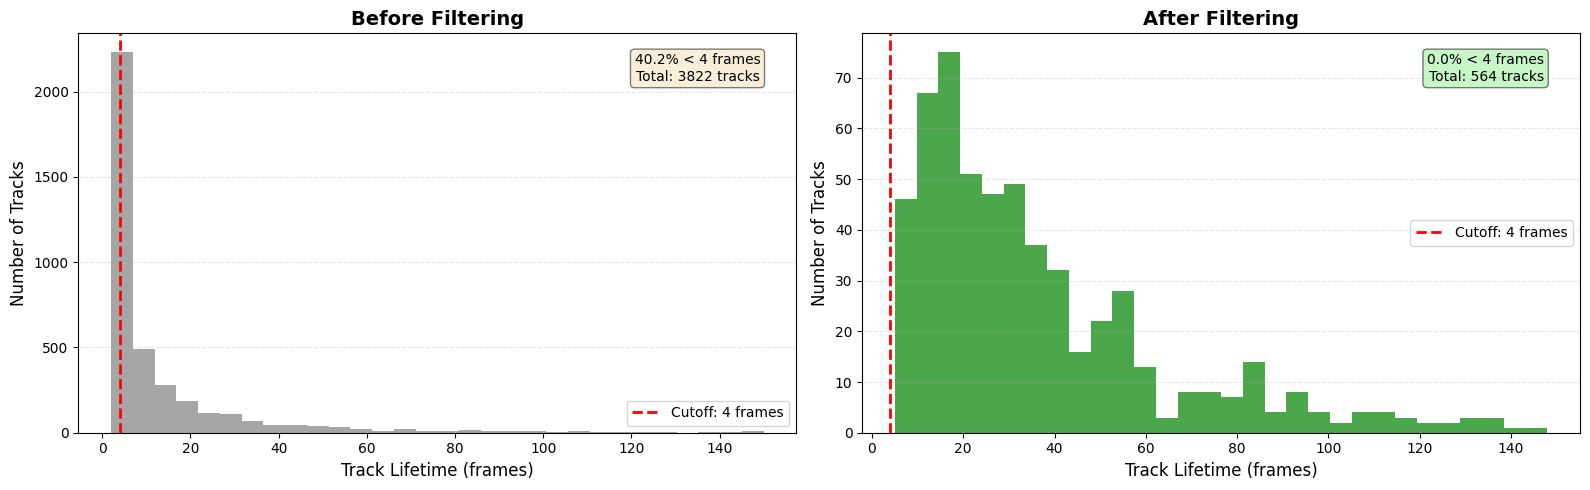

In [293]:
# Show histogram of lifetimes before and after filtering side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Before filtering
ax1.hist(tracks_df['track_length'], bins=30, color='gray', alpha=0.7)
ax1.axvline(x=threshold_length, color='red', linestyle='--', linewidth=2, label=f'Cutoff: {threshold_length} frames')
ax1.set_title('Before Filtering', fontsize=14, fontweight='bold')
ax1.set_xlabel('Track Lifetime (frames)', fontsize=12)
ax1.set_ylabel('Number of Tracks', fontsize=12)
ax1.legend()
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Calculate percentage under cutoff (before)
percentage_before = (tracks_df[tracks_df['track_length'] < threshold_length].shape[0] / tracks_df.shape[0]) * 100
ax1.text(0.95, 0.95, f'{percentage_before:.1f}% < {threshold_length} frames\nTotal: {tracks_df.shape[0]} tracks',
         transform=ax1.transAxes, fontsize=10, verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# After filtering
ax2.hist(peak_filtered_tracks_df['track_length'], bins=30, color='green', alpha=0.7)
ax2.axvline(x=threshold_length, color='red', linestyle='--', linewidth=2, label=f'Cutoff: {threshold_length} frames')
ax2.set_title('After Filtering', fontsize=14, fontweight='bold')
ax2.set_xlabel('Track Lifetime (frames)', fontsize=12)
ax2.set_ylabel('Number of Tracks', fontsize=12)
ax2.legend()
ax2.grid(axis='y', alpha=0.3, linestyle='--')

# Calculate percentage under cutoff (after)
percentage_after = (peak_filtered_tracks_df[peak_filtered_tracks_df['track_length'] < threshold_length].shape[0] / peak_filtered_tracks_df.shape[0]) * 100
ax2.text(0.95, 0.95, f'{percentage_after:.1f}% < {threshold_length} frames\nTotal: {peak_filtered_tracks_df.shape[0]} tracks',
         transform=ax2.transAxes, fontsize=10, verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

plt.tight_layout()
plt.show()

In [173]:
def plot_peak_distribution(peak_analysis_results, title='Distribution of AP2 Peaks per Track'):
    '''
    Plots the distribution of peak counts across tracks.

    Parameters:
    peak_analysis_results (dict): Output from analyze_ap2_peak_distribution
    title (str): Title for the plot
    '''
    distribution = peak_analysis_results['distribution']
    stats = peak_analysis_results['stats']
    
    # Single plot - just the distribution
    fig, ax = plt.subplots(figsize=(8, 5))
    
    # Bar plot of distribution
    ax.bar(distribution.index, distribution.values, color='skyblue', edgecolor='black', alpha=0.7)
    ax.set_xlabel('Number of Peaks', fontsize=12, fontweight='bold')
    ax.set_ylabel('Number of Tracks', fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed summary
    total_tracks = len(peak_analysis_results['peak_counts'])
    print(f"\nDistribution by peak count:")
    for num_peaks, count in distribution.items():
        percentage = (count / total_tracks) * 100
        print(f"  {int(num_peaks)} peak(s): {count} tracks ({percentage:.1f}%)")

Counting AP2 Peaks:   0%|          | 0/564 [00:00<?, ?it/s]

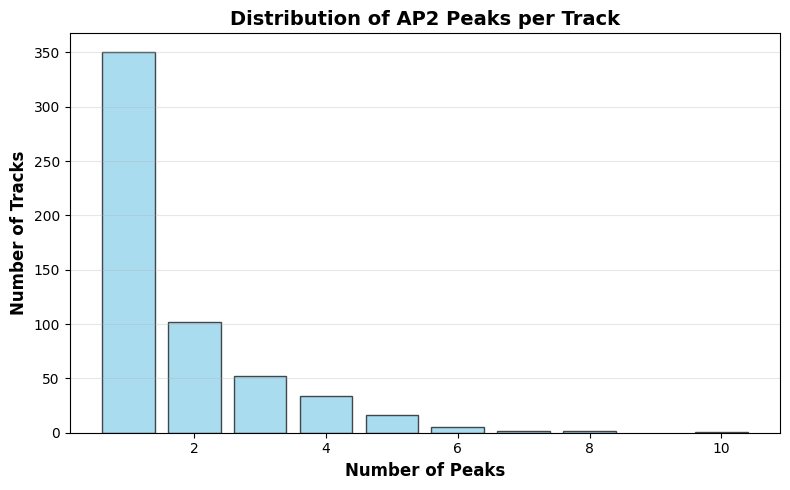


Distribution by peak count:
  1 peak(s): 350 tracks (62.1%)
  2 peak(s): 102 tracks (18.1%)
  3 peak(s): 52 tracks (9.2%)
  4 peak(s): 34 tracks (6.0%)
  5 peak(s): 16 tracks (2.8%)
  6 peak(s): 5 tracks (0.9%)
  7 peak(s): 2 tracks (0.4%)
  8 peak(s): 2 tracks (0.4%)
  10 peak(s): 1 tracks (0.2%)


In [294]:
# Example: Analyze AP2 peak distribution on your filtered tracks
# You can run this on any dataframe: tracks_df, filtered_tracks_df, valid_c3_tracks, etc.

peak_results = analyze_ap2_peak_distribution(
    tracks=peak_filtered_tracks_df,  # Change this to analyze different track sets
    channel='c3_voxel_sum_adjusted',  # AP2 channel
    n_sigma=1.5  # Adjust threshold if needed
)

# Plot the distribution
plot_peak_distribution(peak_results, title='Distribution of AP2 Peaks per Track')

In [29]:
testing = orderFilters(tracks_df, doPixelFilter=True, pixel_order=0, pixel_edge=5, x_max=z2.shape[4], y_max=z2.shape[3], z_max=z2.shape[2],
                    doFrameFilter=True, frame_order=1, filter_start=0, filter_end=z2.shape[0],
                    doAP2PeakFilter=True, ap2_order=2, ap2_peak=1, isGreaterPeak=True,
                    doDynminBurstFilter=True, dynmin_order=3, dist_max=10,
                    doLinearityFilter=False, linearity_order=4, window_size=4, r2_threshold=0.9, two_slopes=True)

Filter step 0, Applying filter_pixel_spots...
After filter_pixel_spots: 3681 tracks remain, 141 tracks dropped.
Filter step 1, Applying filter_track_frames...
After filter_track_frames: 3373 tracks remain, 308 tracks dropped.
Filter step 2, Applying filter_ap2_peaks...


Processing AP2 Peaks:   0%|          | 0/3373 [00:00<?, ?it/s]

After filter_ap2_peaks: 564 tracks remain, 2809 tracks dropped.
Filter step 3, Applying filter_dynmin_bursts...


Processing tracks for dynmin bursts:   0%|          | 0/564 [00:00<?, ?it/s]

After filter_dynmin_bursts: 186 tracks remain, 378 tracks dropped.
Final number of tracks after all filters:, 186 and total tracks dropped: 3636


In [30]:
testing['ap2_peaks_dropped']

,mu_x,mu_y,mu_z,track_id,track_length,track_start,track_end,c3_peak,c2_peak,c1_peak,...,c1_voxel_sum_adjusted,c3_voxel_sum_adjusted_peak,c2_voxel_sum_adjusted_peak,c1_voxel_sum_adjusted_peak,c3_voxel_sum_adjusted_peak_frame,c2_voxel_sum_adjusted_peak_frame,c1_voxel_sum_adjusted_peak_frame,max_z_movement,max_y_movement,max_x_movement
0,332 95.0 930 96.0 1298 95.0 1534 ...,332 203.0 930 202.0 1298 201.0 1534...,332 41.0 930 41.0 1298 41.0 1534 ...,318,21,1,21,165.611429,186.097143,297.377143,...,"[-5.9473684210533975, -993.1842105263204, -59....",4244.947368,1190.710526,2140.342105,5,4,7,5.0,3.0,3.0
1,363 218.0 887 218.0 1292 218.0 1624...,363 96.0 887 96.0 1292 96.0 1624 ...,363 74.0 887 73.0 1292 73.0 1624 ...,319,18,1,18,180.428571,189.960000,350.045714,...,"[-564.3947368421068, 640.3421052631529, -693.1...",5034.947368,891.026316,1408.263158,13,18,5,3.0,2.0,3.0
2,408 240.0 980 240.0 1293 240.0 1694...,408 146.0 980 146.0 1293 146.0 1694...,408 98.0 980 98.0 1293 99.0 1694 ...,322,7,1,7,144.725714,234.457143,750.548571,...,"[-256.0263157894806, -1467.1578947368544, -883...",2044.763158,408.947368,-255.868421,4,1,5,2.0,1.0,1.0
3,413 238.0 984 238.0 1315 239.0 1686...,413 186.0 984 185.0 1315 185.0 1686...,413 100.0 984 100.0 1315 99.0 1686...,323,12,1,14,161.428571,284.337143,764.114286,...,"[7476.421052631573, 6699.210526315786, 3748.15...",2189.473684,3378.368421,7860.131579,2,2,4,8.0,5.0,4.0
4,389 111.0 990 111.0 1304 111.0 1652...,389 306.0 990 306.0 1304 306.0 1652...,389 47.0 990 47.0 1304 46.0 1652 ...,324,6,1,6,145.988571,166.405714,323.680000,...,"[-142.8421052631602, -1168.815789473687, -751....",2598.500000,1195.684211,369.736842,5,5,6,3.0,2.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2804,"49618 174.0 49968 175.0 Name: mu_x, dtyp...","49618 244.0 49968 245.0 Name: mu_y, dtyp...","49618 90.0 49968 90.0 Name: mu_z, dtype:...",3817,2,148,149,158.280000,168.520000,336.891429,...,"[-650.5263157894806, 652.0526315789466]",2081.236842,494.289474,652.052632,148,148,149,0.0,1.0,1.0
2805,"49619 238.0 49964 238.0 Name: mu_x, dtyp...","49619 134.0 49964 134.0 Name: mu_y, dtyp...","49619 92.0 49964 91.0 Name: mu_z, dtype:...",3818,2,148,149,154.537143,418.131429,992.605714,...,"[-1074.921052631602, -1589.3684210526408]",1972.947368,2275.631579,-1074.921053,149,149,148,1.0,0.0,0.0
2806,"49638 197.0 49960 200.0 Name: mu_x, dtyp...","49638 106.0 49960 106.0 Name: mu_y, dtyp...","49638 99.0 49960 100.0 Name: mu_z, dtyp...",3819,2,148,149,135.525714,308.194286,750.834286,...,"[-3327.9210526315874, 172.97368421050487]",1160.421053,9135.315789,172.973684,149,149,149,1.0,0.0,3.0
2807,"49634 224.0 49953 224.0 Name: mu_x, dtyp...","49634 206.0 49953 205.0 Name: mu_y, dtyp...","49634 98.0 49953 99.0 Name: mu_z, dtype:...",3820,2,148,149,150.674286,264.720000,710.817143,...,"[6417.342105263146, 4208.868421052626]",2022.605263,4135.210526,6417.342105,148,149,148,1.0,1.0,0.0


#### Intensities of dropped tracks

In [34]:
def test_intensity_time_plot(dataframe: pd.DataFrame, tracks_to_plot: np.ndarray, track_id_col_name: str, 
                       frame_col_name: str, intensity_to_plot: list, channels_to_plot: int, legend_values: list = ['Channel 3', 'Channel 2', 'Channel 1'], 
                       line_colors: list = ['red', 'green', 'blue'], graph_title = 'Intensity', normalized: bool = False):
    
    '''
    
    The function takes in the list of track ids assigned to a cohort and aligns them with respect to their 
    peak values to a specific index. The index depends on bufferZero. Whatever the value of bufferZero is the
    peaks will be aligned with that value. 
    
    Parameters:
    1. dataframe: type(DataFrame), this is the raw dataframe which contains all of the relevant intensity values
    1. tracks_to_plot: type(list), contains the tracks id's of tracks within the specified length range
    4. intensity_to_plot, type(list), the name of the columns to be used for plotting intensity. Note that the first value
    in this list should be for the primary channel, second value for the secondary channel and so on. 
    Default Value: ['amplitude', 'c2_peak']
    5. track_id_col_name: type(str), the column name which contains the frame number. Default value: 'track_id'
    6. legend_values: type(list), labels for the legend. Must be in line with intensity_to_plot list. The channel that is first in intensity_to_plot
    must also appear first in legend labels. 
    7. line_colors: type(list), colors for the intensity_to_plot lines. line_colors[0] will be the color for intensity_to_plot[0] and so on. 
    8. normalized: type(bool), if the intensity values are normalized. Default value: False

    Output: 
    1. Returns the array of primary channel tracks aligned with respect to secondary channel peaks
    2. Returns the array of secondary channel tracks where tracks are aligned with all peaks of tracks being on 
    the same index. (the index is determined by bufferZero)
    
    '''


    if channels_to_plot == 3 and len(intensity_to_plot) != 3: 
        raise ValueError('length of intensity_to_plot must equal channels_to_plot')
        
    num_rows = 1
    num_cols = 5
    fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(17.5, 6))
    axes = axes.flatten() if isinstance(axes, np.ndarray) else np.array([axes])
    handles = []
    labels = []

    for i, track_id in enumerate(tracks_to_plot):
        # Filter DataFrame for the selected track_id
        track_data = dataframe[dataframe[track_id_col_name] == track_id].copy(deep = True)

        #length = filtered_df[filtered_df['track_id'] == track_id]['track_length'].values
        length = track_data.shape[0]

        lines = []
        for j in range(channels_to_plot):
            min_val = track_data[intensity_to_plot[j]].min()
            track_data[intensity_to_plot[j]] -= min_val
            max_val = track_data[intensity_to_plot[j]].max()          

            # normalize by max_intensity
            if normalized:  
                track_data[intensity_to_plot[j]] /= max_val
            line, = axes[i].plot(track_data[frame_col_name], track_data[intensity_to_plot[j]], label=intensity_to_plot[j], color=line_colors[j])
            lines.append(line)

        # if channels_to_plot == 2:
        #     min0 = track_data[intensity_to_plot[0]].min()
        #     min1 = track_data[intensity_to_plot[1]].min()
        #     track_data[intensity_to_plot[0]] = track_data[intensity_to_plot[0]] - min0
        #     track_data[intensity_to_plot[1]] = track_data[intensity_to_plot[1]] - min1
        #     line1, = axes[row, col].plot(track_data[frame_col_name], track_data[intensity_to_plot[0]], label=intensity_to_plot[0], color = line_colors[0])
        #     line2, = axes[row, col].plot(track_data[frame_col_name], track_data[intensity_to_plot[1]], label=intensity_to_plot[1], color = line_colors[1])
        # else: 
        #     min0 = track_data[intensity_to_plot[0]].min()
        #     min1 = track_data[intensity_to_plot[1]].min()
        #     min2 = track_data[intensity_to_plot[2]].min()
        #     track_data[intensity_to_plot[0]] = track_data[intensity_to_plot[0]] - min0
        #     track_data[intensity_to_plot[1]] = track_data[intensity_to_plot[1]] - min1
        #     track_data[intensity_to_plot[2]] = track_data[intensity_to_plot[2]] - min2
        #     line1, = axes[row, col].plot(track_data[frame_col_name], track_data[intensity_to_plot[0]], label=intensity_to_plot[0], color = line_colors[0])
        #     line2, = axes[row, col].plot(track_data[frame_col_name], track_data[intensity_to_plot[1]], label=intensity_to_plot[1],  color = line_colors[1])
        #     line3, = axes[row, col].plot(track_data[frame_col_name], track_data[intensity_to_plot[2]], label=intensity_to_plot[2], color = line_colors[2])
        axes[i].set_title(f'Track {track_id}, length {length}')
        axes[i].set_xlabel('Frame')
        axes[i].set_ylabel('Intensity')
        #axes[row, col].legend()

    fig.suptitle(f'{graph_title} over time', fontsize = 16, fontweight = 'bold')

    for i in range(channels_to_plot):
        handles.append(lines[i])
        labels.append(legend_values[i])
    # if (channels_to_plot == 2):
    #     # Set a single legend for all subplots
    #     handles.extend([line1, line2])
    #     labels.extend([legend_values[0], legend_values[1]])
    # else: 
    #     # Set a single legend for all subplots
    #     handles.extend([line1, line2, line3])
    #     labels.extend([legend_values[0], legend_values[1], legend_values[2]])
        
    # Set a single legend for all subplots
    fig.legend(handles, labels, loc='upper right', ncol=channels_to_plot, fontsize=18)
    # Adjust layout for better spacing
    # Adjust layout for better spacing
    plt.tight_layout()
    plt.subplots_adjust(top=0.8, hspace=0.7)
    #fig.suptitle(f'Intensity over time \n Channel 3 color: red \n Channel 2 color: green \n Channel 1 color: blue', fontsize=18, fontweight='bold')
    #plt.subplots_adjust(top=0.90)
    plt.show()

In [212]:
filtered_tracks_df

,mu_x,mu_y,mu_z,track_id,track_length,track_start,track_end,c3_peak,c2_peak,c1_peak,...,c1_voxel_sum_adjusted_peak,c3_voxel_sum_adjusted_peak_frame,c2_voxel_sum_adjusted_peak_frame,c1_voxel_sum_adjusted_peak_frame,max_z_movement,max_y_movement,max_x_movement,channel2_positive,channel1_positive,membrane_region
0,4 192.0 15 193.0 62 193.0 84 ...,4 129.0 15 129.0 62 130.0 84 ...,4 92.0 15 92.0 62 92.0 84 ...,434,18,5,23,143.502857,214.560000,554.188571,...,1536.052632,14,17,17,4.0,4.0,6.0,True,False,Basal
1,5 189.0 32 189.0 47 188.0 92 ...,5 261.0 32 261.0 47 262.0 92 ...,5 90.0 32 90.0 47 91.0 92 ...,441,17,5,23,162.365714,187.697143,380.822857,...,2275.815789,13,8,8,7.0,3.0,4.0,True,False,Basal
2,3 75.0 30 75.0 85 75.0 180 ...,3 154.0 30 154.0 85 155.0 180 ...,3 18.0 30 20.0 85 20.0 180 ...,450,18,5,23,126.080000,152.765714,286.182857,...,1010.947368,14,17,8,4.0,3.0,1.0,True,False,Basal
3,20 141.0 48 140.0 108 140.0 142 ...,20 44.0 48 44.0 108 44.0 142 ...,20 43.0 48 42.0 108 43.0 142 ...,456,27,6,32,125.017143,147.245714,446.325714,...,12674.973684,15,7,19,5.0,3.0,3.0,True,False,Basal
4,22 262.0 44 263.0 117 262.0 137 ...,22 320.0 44 320.0 117 319.0 137 ...,22 103.0 44 102.0 117 103.0 137 ...,459,26,6,33,143.222857,170.297143,348.205714,...,4997.842105,18,17,30,6.0,4.0,3.0,True,True,Basal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
136,20054 192.0 20247 192.0 20405 192.0 2...,20054 276.0 20247 276.0 20405 276.0 2...,20054 88.0 20247 87.0 20405 87.0 2058...,2940,20,114,134,154.868571,161.834286,483.857143,...,8963.815789,122,119,115,6.0,4.0,2.0,True,True,Basal
137,20064 232.0 20251 231.0 20289 232.0 2...,20064 201.0 20251 201.0 20289 201.0 2...,20064 83.0 20251 82.0 20289 83.0 2084...,2950,29,114,144,151.885714,187.891429,408.240000,...,1517.657895,121,115,141,4.0,3.0,2.0,True,False,Basal
138,20013 237.0 20091 238.0 20527 238.0 2...,20013 259.0 20091 260.0 20527 260.0 2...,20013 90.0 20091 90.0 20527 89.0 2079...,2955,25,114,139,148.640000,163.571429,303.051429,...,1577.736842,125,120,130,5.0,2.0,4.0,True,False,Basal
139,20264 218.0 20480 218.0 20487 218.0 2...,20264 262.0 20480 262.0 20487 262.0 2...,20264 79.0 20480 80.0 20487 80.0 2086...,2961,21,115,136,169.725714,189.022857,356.920000,...,3298.921053,129,119,124,4.0,2.0,3.0,True,False,Basal


In [213]:
value_to_plot = 'voxel_sum_adjusted'

# set 'normalized = False' to plot raw intensities

random_tracks = random_track_ids(dataframe = testing["ap2_peaks_dropped"], desired_length = [0, np.inf], 
                                 track_length_col_name = 'track_length', track_id_col_name = 'track_id', 
                                num_to_select = 5)

test_intensity_time_plot(dataframe = track_df, tracks_to_plot = random_tracks, 
intensity_to_plot = [f'c3_{value_to_plot}',f'c2_{value_to_plot}', f'c1_{value_to_plot}'], track_id_col_name = 'track_id', 
frame_col_name = 'frame', channels_to_plot = 3, legend_values = [channel3_name, channel2_name, channel1_name],
line_colors = ['magenta', 'lime', 'blue'], graph_title = f'{value_to_plot}', normalized=False)

KeyError: 'ap2_peaks_dropped'

In [37]:
z_max = z2.shape[2]
y_max = z2.shape[3]
x_max = z2.shape[4]
print("x_max:", x_max, "y_max:", y_max, "z_max:", z_max)

x_max: 303 y_max: 350 z_max: 114


Filter out tracks based on length and completeness

### Determining Valid Channel 3 tracks 
valid_c3_tracks will serve as baseline "clathrin positive" and valid tracks

In [295]:
#Already determined valid tracks perviously so:
valid_c3_tracks = length_filtered_tracks_df.copy(deep = True)  

# ### Dropping tracks with Channel 3 peak in the last frame
# # valid_c3_tracks = drop_last_frame_peak_tracks(df = length_filtered_tracks_df, intensity_col = 'c3_peak_frame')
# valid_c3_tracks = drop_last_frame_peak_tracks(df = length_filtered_tracks_df, intensity_col = 'c3_voxel_sum_adjusted_peak_frame')

# ### Dropping tracks with Channel 3 which have their peaks in the first three frames 
# # valid_c3_tracks = drop_early_peak_tracks(df = valid_c3_tracks, intensity_peak_frame = 'c3_peak_frame',
# #                                       cutoff = peak_cutoff)
# valid_c3_tracks = drop_early_peak_tracks(df = valid_c3_tracks, intensity_peak_frame = 'c3_voxel_sum_adjusted_peak_frame',
#                                       cutoff = peak_cutoff)

print(len(valid_c3_tracks))
valid_c3_tracks.head()


564


,mu_x,mu_y,mu_z,track_id,track_length,track_start,track_end,c3_peak,c2_peak,c1_peak,...,c1_voxel_sum_adjusted,c3_voxel_sum_adjusted_peak,c2_voxel_sum_adjusted_peak,c1_voxel_sum_adjusted_peak,c3_voxel_sum_adjusted_peak_frame,c2_voxel_sum_adjusted_peak_frame,c1_voxel_sum_adjusted_peak_frame,max_z_movement,max_y_movement,max_x_movement
0,443 139.0 846 139.0 1259 139.0 1...,443 119.0 846 119.0 1259 119.0 1...,443 54.0 846 54.0 1259 55.0 1428...,311,93,1,94,194.605714,191.617143,387.948571,...,"[685.9999999999927, 177.81578947367962, 107.42...",6379.684211,1750.368421,6150.578947,8,6,86,15.0,4.0,10.0
1,393 204.0 910 205.0 1289 204.0 1...,393 232.0 910 233.0 1289 232.0 1...,393 99.0 910 97.0 1289 100.0 1...,312,82,1,82,173.445714,179.057143,350.920000,...,"[1743.6578947368398, 1010.3421052631529, -269....",4881.947368,999.421053,1743.657895,74,12,1,7.0,4.0,4.0
2,392 198.0 891 198.0 1291 198.0 1...,392 268.0 891 269.0 1291 269.0 1...,392 94.0 891 94.0 1291 92.0 1396...,313,57,1,57,201.931429,204.000000,521.182857,...,"[3245.6315789473592, 1895.3157894736796, 2091....",6936.684211,1041.500000,11208.315789,39,43,57,10.0,4.0,3.0
3,405 190.0 911 191.0 1305 190.0 1...,405 124.0 911 124.0 1305 124.0 1...,405 101.0 911 100.0 1305 100.0 1...,314,48,1,48,148.451429,218.828571,593.508571,...,"[574.526315789466, -1149.5263157894806, -778.5...",2061.236842,1353.000000,3250.184211,1,19,45,5.0,3.0,6.0
4,406 259.0 912 259.0 1306 258.0 1...,406 113.0 912 113.0 1306 114.0 1...,406 110.0 912 109.0 1306 111.0 1...,315,50,1,51,170.108571,182.125714,357.662857,...,"[-5.870967741931963, 171.6052631578932, 401.51...",3426.236842,549.868421,1109.026316,19,12,42,7.0,4.0,4.0


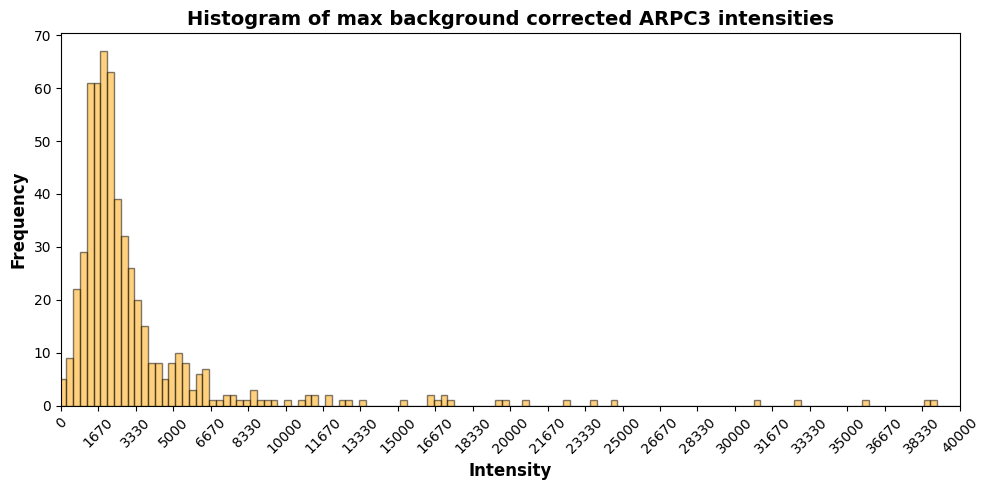

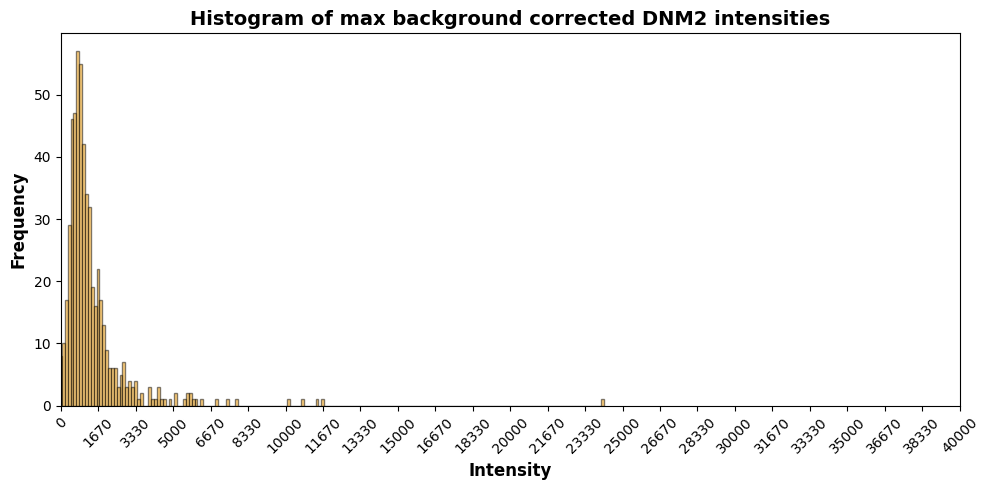

In [296]:
# Histogram of maximum background corrected ARPC3 intensity values, to determine cutoff for ARPC3-positive tracks
columns = ['c1_voxel_sum_adjusted_peak', 'c2_voxel_sum_adjusted_peak']
marker = ['ARPC3', 'DNM2']

# # Max AP2 intensity per track
# control_AP2 = tracks_channel_subset_control['C3_adjusted_voxel_sum'].reset_index(drop=True)

# max_control_AP2 = []
# for j in range(len(control_AP2)):
#     max_control_AP2.append(max(control_AP2[j]))  

for i in range(len(columns)):
    # Create a figure with 2 subplots side by side
    fig, ax1 = plt.subplots(1, 1, figsize=(10, 5))

    control =  valid_c3_tracks[columns[i]].reset_index(drop=True)
    

    max_control = []
    for j in range(len(control)):
        max_control.append(control[j])  # For every element in arpc3_control, get the max value



    # # Normalize to max AP2 intensity, optional
    # max_control = (np.array(max_control) / np.array(max_control_AP2)).tolist()
    


    # Generate 50 equally spaced bins between the min and max of max_arpc3_control and max_arpc3_OS
    # so I can plot the histograms of max_arpc3_control and max_arpc3_OS on the same plot
    # with the same binning
    bins = np.linspace(min(max_control), max(max_control), 200)


    # Plot histogram on the first subplot
    ax1.hist(max_control, bins=bins, color='orange', edgecolor='black', alpha=0.5, label='Control')

    # Calculate the data range
    # x_min = min(max_control)
    # x_max = max(max_control)
    x_min = 0
    x_max = 40000
    
    # Round minimum down and maximum up to nearest 10
    x_min_rounded = np.floor(x_min / 10) * 10
    x_max_rounded = np.ceil(x_max / 10) * 10
    
    # Create tick marks rounded to the nearest 10
    num_ticks =25  # Adjust this number for more or fewer ticks
    
    # Generate ticks rounded to the nearest 10
    x_ticks = np.linspace(x_min_rounded, x_max_rounded, num_ticks)
    x_ticks_rounded = np.round(x_ticks / 10) * 10  # Round to nearest 10
    
    ax1.set_xticks(x_ticks_rounded)
    ax1.set_xticklabels([f'{int(x)}' for x in x_ticks_rounded], rotation=45, fontsize=10)
    
    ax1.set_xlabel('Intensity', fontsize=12, weight='bold')
    ax1.set_ylabel('Frequency', fontsize=12, weight='bold')
    ax1.set_title('Histogram of max background corrected' + ' ' + marker[i] + ' ' +  'intensities', fontsize=14, weight='bold')

    # set x limit to 0 and 20000
    ax1.set_xlim(x_min_rounded, x_max_rounded)

    # Adjust layout
    plt.tight_layout()
    plt.show()

In [29]:
# valid_c3_tracks_filter = valid_c3_tracks[valid_c3_tracks['C1_adjusted_voxel_sum_peak'] > 4000]

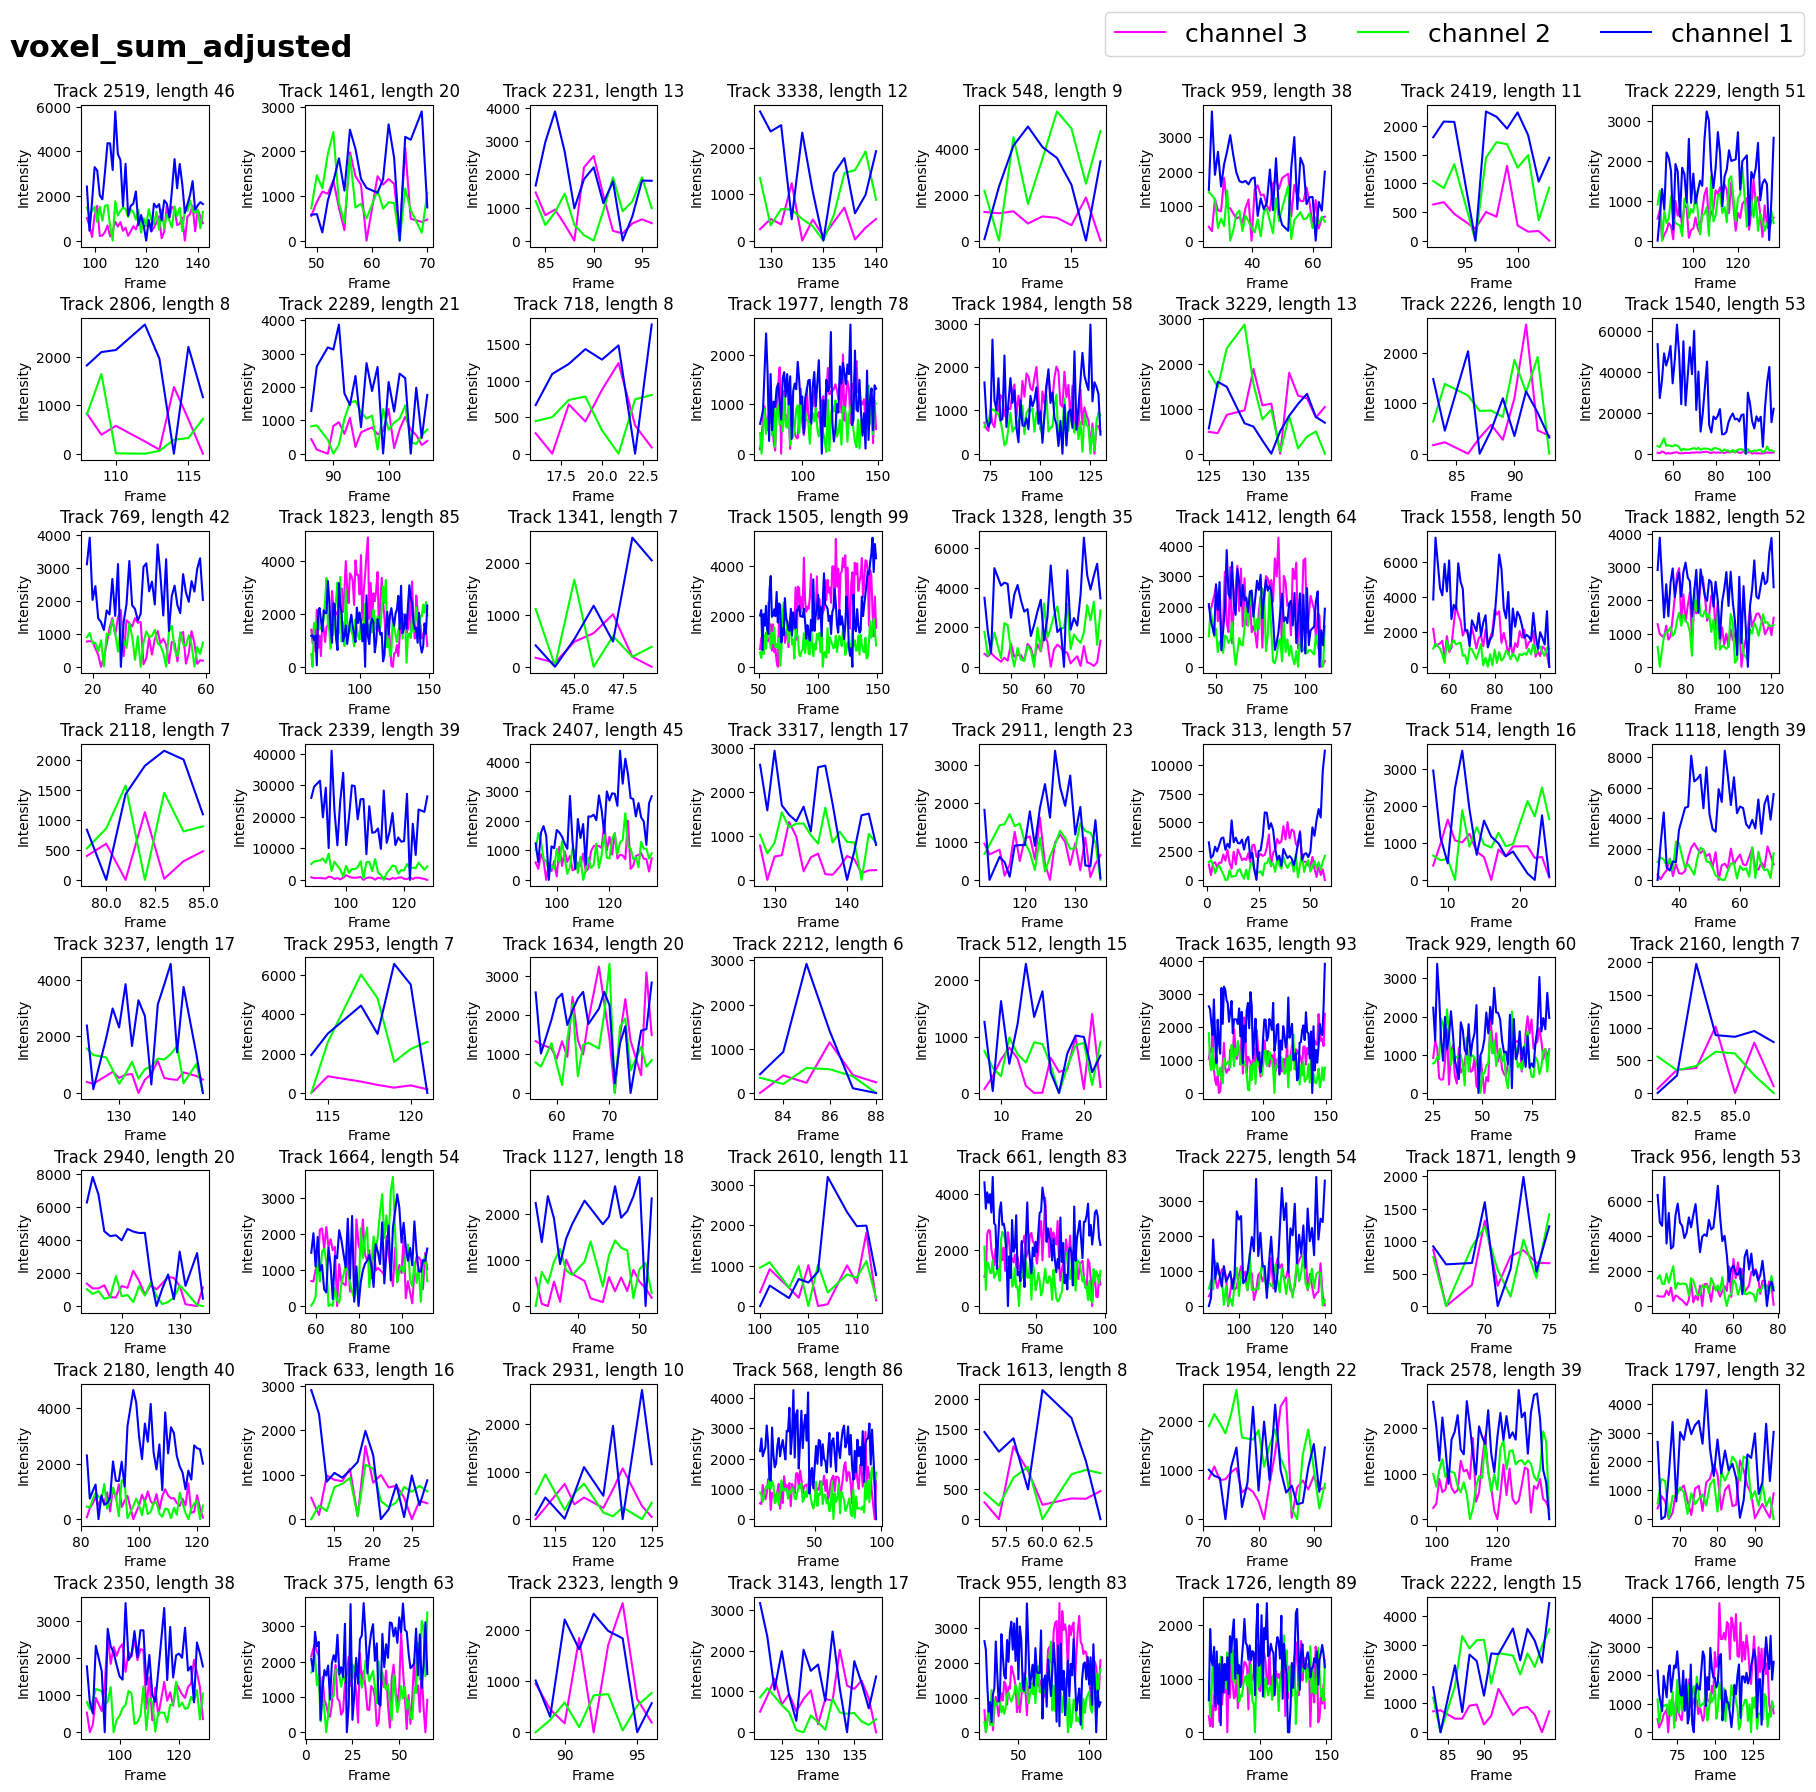

In [297]:
from intensity_time_plots import filter_track_ids_by_length_ranges, random_track_ids
from intensity_time_plots import intensity_time_plot, createBufferForLifetimeCohort
from intensity_time_plots import createBufferForLifetimeCohort_normalized, cumulative_plots, cumulative_plots_ax
value_to_plot = 'voxel_sum_adjusted'

# set 'normalized = False' to plot raw intensities

random_tracks = random_track_ids(dataframe = valid_c3_tracks, desired_length = [0, np.inf], 
                                 track_length_col_name = 'track_length', track_id_col_name = 'track_id', 
                                num_to_select = 64)

intensity_time_plot(dataframe = track_df, tracks_to_plot = random_tracks, 
intensity_to_plot = [f'c3_{value_to_plot}',f'c2_{value_to_plot}', f'c1_{value_to_plot}'], track_id_col_name = 'track_id', 
frame_col_name = 'frame', channels_to_plot = 3, legend_values = [channel3_name, channel2_name, channel1_name],
line_colors = ['magenta', 'lime', 'blue'], graph_title = f'{value_to_plot}', normalized=False)

### Filtering for Channel 2 
dnm2_positive_tracks will serve as the baseline for dynamin positive tracks

In [298]:
# Channel 2-positive tracks

# dnm2_positive_tracks = drop_tracks_below_intensity(df = valid_c3_tracks, threshold = threshold_intensity_channel_2, 
#                                           intensity_peak_frame = 'c2_peak')

dnm2_positive_tracks = drop_tracks_below_intensity(df = valid_c3_tracks, threshold = threshold_intensity_channel_2, 
                                          intensity_peak_frame = 'c2_voxel_sum_adjusted_peak')

### Filter tracks based on channel 2 peak if occurs within 3 frames of starting of a track 

# dnm2_positive_tracks = drop_early_peak_tracks(df = dnm2_positive_tracks, intensity_peak_frame = 'c2_peak_frame', 
#                                       cutoff = peak_cutoff)

dnm2_positive_tracks = drop_early_peak_tracks(df = dnm2_positive_tracks, intensity_peak_frame = 'c2_voxel_sum_adjusted_peak_frame', 
                                      cutoff = peak_cutoff)

### Filter tracks based on channel 2 peaks occuring in the last frame 

# dnm2_positive_tracks = drop_last_frame_peak_tracks(df = dnm2_positive_tracks, intensity_col = 'c2_peak_frame')

dnm2_positive_tracks = drop_last_frame_peak_tracks(df = dnm2_positive_tracks, intensity_col = 'c2_voxel_sum_adjusted_peak_frame')
dnm2_positive_tracks.shape
dnm2_positive_tracks.head()

,mu_x,mu_y,mu_z,track_id,track_length,track_start,track_end,c3_peak,c2_peak,c1_peak,...,c1_voxel_sum_adjusted,c3_voxel_sum_adjusted_peak,c2_voxel_sum_adjusted_peak,c1_voxel_sum_adjusted_peak,c3_voxel_sum_adjusted_peak_frame,c2_voxel_sum_adjusted_peak_frame,c1_voxel_sum_adjusted_peak_frame,max_z_movement,max_y_movement,max_x_movement
0,443 139.0 846 139.0 1259 139.0 1...,443 119.0 846 119.0 1259 119.0 1...,443 54.0 846 54.0 1259 55.0 1428...,311,93,1,94,194.605714,191.617143,387.948571,...,"[685.9999999999927, 177.81578947367962, 107.42...",6379.684211,1750.368421,6150.578947,8,6,86,15.0,4.0,10.0
1,393 204.0 910 205.0 1289 204.0 1...,393 232.0 910 233.0 1289 232.0 1...,393 99.0 910 97.0 1289 100.0 1...,312,82,1,82,173.445714,179.057143,350.920000,...,"[1743.6578947368398, 1010.3421052631529, -269....",4881.947368,999.421053,1743.657895,74,12,1,7.0,4.0,4.0
2,392 198.0 891 198.0 1291 198.0 1...,392 268.0 891 269.0 1291 269.0 1...,392 94.0 891 94.0 1291 92.0 1396...,313,57,1,57,201.931429,204.000000,521.182857,...,"[3245.6315789473592, 1895.3157894736796, 2091....",6936.684211,1041.500000,11208.315789,39,43,57,10.0,4.0,3.0
3,405 190.0 911 191.0 1305 190.0 1...,405 124.0 911 124.0 1305 124.0 1...,405 101.0 911 100.0 1305 100.0 1...,314,48,1,48,148.451429,218.828571,593.508571,...,"[574.526315789466, -1149.5263157894806, -778.5...",2061.236842,1353.000000,3250.184211,1,19,45,5.0,3.0,6.0
4,406 259.0 912 259.0 1306 258.0 1...,406 113.0 912 113.0 1306 114.0 1...,406 110.0 912 109.0 1306 111.0 1...,315,50,1,51,170.108571,182.125714,357.662857,...,"[-5.870967741931963, 171.6052631578932, 401.51...",3426.236842,549.868421,1109.026316,19,12,42,7.0,4.0,4.0


### Identifying Channel 1 positive tracks 

In [299]:
### Identifying Actin Positive Tracks 
# actin_positive_tracks = drop_tracks_below_intensity(df = valid_c3_tracks, threshold = threshold_intensity_channel_1, 
#                                           intensity_peak_frame = 'c1_peak' )

actin_positive_tracks = drop_tracks_below_intensity(df = valid_c3_tracks, threshold = threshold_intensity_channel_1, 
                                          intensity_peak_frame = 'c1_voxel_sum_adjusted_peak' )

### Filter tracks based on channel 1 peaks if occurs within the first 3 frames 

# actin_positive_tracks = drop_early_peak_tracks(df = actin_positive_tracks, intensity_peak_frame = 'c1_peak_frame', 
#                                       cutoff = peak_cutoff)

actin_positive_tracks = drop_early_peak_tracks(df = actin_positive_tracks, intensity_peak_frame = 'c1_voxel_sum_adjusted_peak_frame', 
                                      cutoff = peak_cutoff)

# actin_positive_tracks = drop_last_frame_peak_tracks(df = actin_positive_tracks, intensity_col = 'c1_peak_frame')

actin_positive_tracks = drop_last_frame_peak_tracks(df = actin_positive_tracks, intensity_col = 'c1_voxel_sum_adjusted_peak_frame')

Combining actin and dynamin positive tracks with valid clathrin positive tracks 

In [300]:
final_tracks = valid_c3_tracks.copy(deep = True)
final_tracks['channel2_positive'] = False 
final_tracks['channel1_positive'] = False 

print("Total valid C3 tracks:", len(final_tracks))

Total valid C3 tracks: 564


In [301]:
# ***Setting actin positive tracks to True***

# Get the track IDs from actin_positive_tracks
actin_positive_track_ids = actin_positive_tracks['track_id']

# Set 'actin_positive' to True for rows where 'track_id' is in positive_track_ids
final_tracks.loc[final_tracks['track_id'].isin(actin_positive_track_ids), 'channel1_positive'] = True

actin_rows_count = final_tracks[final_tracks['channel1_positive'] == True].shape[0]
print(f'number of {channel1_name} positive tracks are: {actin_rows_count}')

# ***Setting dynamin positive tracks to True***

# Get the track IDs from actin_positive_tracks
dnm2_positive_track_ids = dnm2_positive_tracks['track_id']

# Set 'actin_positive' to True for rows where 'track_id' is in positive_track_ids
final_tracks.loc[final_tracks['track_id'].isin(dnm2_positive_track_ids), 'channel2_positive'] = True

dnm2_rows_count = final_tracks[final_tracks['channel2_positive'] == True].shape[0]
print(f'number of {channel2_name} positive tracks are: {dnm2_rows_count}')


actin_dnm2_rows_count = final_tracks[(final_tracks['channel2_positive'] == True) & 
                                     (final_tracks['channel1_positive'] == True)].shape[0]
print(f"number of {channel1_name} and {channel2_name} positive tracks are: {actin_dnm2_rows_count}")

number of channel 1 positive tracks are: 411
number of channel 2 positive tracks are: 399
number of channel 1 and channel 2 positive tracks are: 306


In [302]:
final_tracks.head()

,mu_x,mu_y,mu_z,track_id,track_length,track_start,track_end,c3_peak,c2_peak,c1_peak,...,c2_voxel_sum_adjusted_peak,c1_voxel_sum_adjusted_peak,c3_voxel_sum_adjusted_peak_frame,c2_voxel_sum_adjusted_peak_frame,c1_voxel_sum_adjusted_peak_frame,max_z_movement,max_y_movement,max_x_movement,channel2_positive,channel1_positive
0,443 139.0 846 139.0 1259 139.0 1...,443 119.0 846 119.0 1259 119.0 1...,443 54.0 846 54.0 1259 55.0 1428...,311,93,1,94,194.605714,191.617143,387.948571,...,1750.368421,6150.578947,8,6,86,15.0,4.0,10.0,True,True
1,393 204.0 910 205.0 1289 204.0 1...,393 232.0 910 233.0 1289 232.0 1...,393 99.0 910 97.0 1289 100.0 1...,312,82,1,82,173.445714,179.057143,350.920000,...,999.421053,1743.657895,74,12,1,7.0,4.0,4.0,True,False
2,392 198.0 891 198.0 1291 198.0 1...,392 268.0 891 269.0 1291 269.0 1...,392 94.0 891 94.0 1291 92.0 1396...,313,57,1,57,201.931429,204.000000,521.182857,...,1041.500000,11208.315789,39,43,57,10.0,4.0,3.0,True,False
3,405 190.0 911 191.0 1305 190.0 1...,405 124.0 911 124.0 1305 124.0 1...,405 101.0 911 100.0 1305 100.0 1...,314,48,1,48,148.451429,218.828571,593.508571,...,1353.000000,3250.184211,1,19,45,5.0,3.0,6.0,True,True
4,406 259.0 912 259.0 1306 258.0 1...,406 113.0 912 113.0 1306 114.0 1...,406 110.0 912 109.0 1306 111.0 1...,315,50,1,51,170.108571,182.125714,357.662857,...,549.868421,1109.026316,19,12,42,7.0,4.0,4.0,True,True


In [278]:
# With the new columns added, final_tracks contains the positivity information for both channels

# Print number of tracks that are positive for dnm2 ("so dnm2_positive" == TRUE)
print('DNM2 positive tracks:', filtered_tracks_df['channel2_positive'].sum())
print('ArpC2 positive tracks:', filtered_tracks_df['channel1_positive'].sum())

#Print the number of tracks that are positive for both channels
both_positive_tracks = filtered_tracks_df[(filtered_tracks_df['channel2_positive'] == True) & 
                                         (filtered_tracks_df['channel1_positive'] == True)]
print('Tracks positive for both DNM2 and ArpC2:', len(both_positive_tracks))

DNM2 positive tracks: 111
ArpC2 positive tracks: 46
Tracks positive for both DNM2 and ArpC2: 43


### Estimating Apical/Basal/Lateral boundaries of cell
Based on the slices with the most intensity in channel 1

In [223]:
import importlib
import filters
importlib.reload(filters)

<module 'filters' from '/Users/valerie/LLSM-CME-ANALYSIS/Final/src/filters.py'>

In [303]:
#channel is hard coded in the function right now. Need to allow it to be passed as a parameter by the user 
if membrane_regions_exist == True:      
    boundaries = plot_z_sum_bd(z2)
else: print("Membrane regions do not exist, skipping boundary plot.")
# print(boundaries)

Membrane regions do not exist, skipping boundary plot.


This Z axis plot shows where the max intensities are, which roughly correspond to the basal and apical regions of the cell.

The lines are the auto-detected boundaries between basal, lateral, and apical.  

If needed, you can scan through the z series in Napari below to adjust the position of these boundaries.

In [304]:
# If ychange the values of the boundaries to the ones you want to use

basal_lateral_boundary_slice_manual = []
lateral_apical_boundary_slice_manual = []

if membrane_regions_exist == True and basal_lateral_boundary_slice_manual:
    boundaries = [basal_lateral_boundary_slice_manual, lateral_apical_boundary_slice_manual]
    print('Manual basal-lateral boundary slice is:', basal_lateral_boundary_slice_manual)   
    print('Manual lateral-apical boundary slice is:', lateral_apical_boundary_slice_manual)

elif membrane_regions_exist == True:
    print('Basal-lateral boundary slice is:', boundaries[0])   
    print('Lateral-apical boundary slice is:', boundaries[1]) 

else:
    print('Analyzing whole cell without membrane regions')   



Analyzing whole cell without membrane regions


In [305]:
# Allocate membrane regions based on the boundaries defined above
if membrane_regions_exist == True: 
    allocate_membrane_regions(df = length_filtered_tracks_df, basal_range = [0,25] , lateral_range = [25,75], apical_range = [75,112])

else: 
    final_tracks['membrane_region'] = 'Basal'


# # Allocate membrane regions based on the boundaries defined above
# if membrane_regions_exist == True: 
#     allocate_membrane_regions(df = final_tracks, basal_range = [0,25] , lateral_range = [25,75], apical_range = [75,112])

# else: 
#     final_tracks['membrane_region'] = 'Basal'

In [306]:
# # Subset final tracks such that 25 is less than mean_z less than 30
# final_tracks[(final_tracks['mean_z'] > 25) & (final_tracks['mean_z'] < 30)][['mean_z', 'membrane_region']]
final_tracks.head()

,mu_x,mu_y,mu_z,track_id,track_length,track_start,track_end,c3_peak,c2_peak,c1_peak,...,c1_voxel_sum_adjusted_peak,c3_voxel_sum_adjusted_peak_frame,c2_voxel_sum_adjusted_peak_frame,c1_voxel_sum_adjusted_peak_frame,max_z_movement,max_y_movement,max_x_movement,channel2_positive,channel1_positive,membrane_region
0,443 139.0 846 139.0 1259 139.0 1...,443 119.0 846 119.0 1259 119.0 1...,443 54.0 846 54.0 1259 55.0 1428...,311,93,1,94,194.605714,191.617143,387.948571,...,6150.578947,8,6,86,15.0,4.0,10.0,True,True,Basal
1,393 204.0 910 205.0 1289 204.0 1...,393 232.0 910 233.0 1289 232.0 1...,393 99.0 910 97.0 1289 100.0 1...,312,82,1,82,173.445714,179.057143,350.920000,...,1743.657895,74,12,1,7.0,4.0,4.0,True,False,Basal
2,392 198.0 891 198.0 1291 198.0 1...,392 268.0 891 269.0 1291 269.0 1...,392 94.0 891 94.0 1291 92.0 1396...,313,57,1,57,201.931429,204.000000,521.182857,...,11208.315789,39,43,57,10.0,4.0,3.0,True,False,Basal
3,405 190.0 911 191.0 1305 190.0 1...,405 124.0 911 124.0 1305 124.0 1...,405 101.0 911 100.0 1305 100.0 1...,314,48,1,48,148.451429,218.828571,593.508571,...,3250.184211,1,19,45,5.0,3.0,6.0,True,True,Basal
4,406 259.0 912 259.0 1306 258.0 1...,406 113.0 912 113.0 1306 114.0 1...,406 110.0 912 109.0 1306 111.0 1...,315,50,1,51,170.108571,182.125714,357.662857,...,1109.026316,19,12,42,7.0,4.0,4.0,True,True,Basal


Save tracks

In [307]:
final_tracks.to_pickle(output_directory_full)
print(f"Filtered tracks saved to {output_directory_full}")

Filtered tracks saved to /Volumes/ActiveNAS/Valerie/TransferFolder/20260102_6hIntervals/20251120_66h_SlideB3_Channel2-01_analysis/datasets/peak_filtered_tracks_final.pkl


In [197]:
final_tracks.to_pickle(output_directory_full)
print(f"Final tracks saved to {output_directory_full}")

Final tracks saved to /Volumes/ActiveNAS/Valerie/TransferFolder/20260102_6hIntervals/20251118_24h_SlideA1_Channel3-04_analysis/datasets/peak_filtered_tracks_final.pkl


In [190]:
# Ensure filtered_tracks_df is a proper DataFrame
final_tracks = pd.DataFrame(filtered_tracks_df).reset_index(drop=True)
print(f"Type: {type(filtered_tracks_df)}")
print(f"Shape: {filtered_tracks_df.shape}")
filtered_tracks_df.head()

Type: <class 'pandas.core.frame.DataFrame'>
Shape: (141, 33)


,mu_x,mu_y,mu_z,track_id,track_length,track_start,track_end,c3_peak,c2_peak,c1_peak,...,c1_voxel_sum_adjusted_peak,c3_voxel_sum_adjusted_peak_frame,c2_voxel_sum_adjusted_peak_frame,c1_voxel_sum_adjusted_peak_frame,max_z_movement,max_y_movement,max_x_movement,channel2_positive,channel1_positive,membrane_region
0,4 192.0 15 193.0 62 193.0 84 ...,4 129.0 15 129.0 62 130.0 84 ...,4 92.0 15 92.0 62 92.0 84 ...,434,18,5,23,143.502857,214.560000,554.188571,...,1536.052632,14,17,17,4.0,4.0,6.0,True,False,Basal
1,5 189.0 32 189.0 47 188.0 92 ...,5 261.0 32 261.0 47 262.0 92 ...,5 90.0 32 90.0 47 91.0 92 ...,441,17,5,23,162.365714,187.697143,380.822857,...,2275.815789,13,8,8,7.0,3.0,4.0,True,False,Basal
2,3 75.0 30 75.0 85 75.0 180 ...,3 154.0 30 154.0 85 155.0 180 ...,3 18.0 30 20.0 85 20.0 180 ...,450,18,5,23,126.080000,152.765714,286.182857,...,1010.947368,14,17,8,4.0,3.0,1.0,True,False,Basal
3,20 141.0 48 140.0 108 140.0 142 ...,20 44.0 48 44.0 108 44.0 142 ...,20 43.0 48 42.0 108 43.0 142 ...,456,27,6,32,125.017143,147.245714,446.325714,...,12674.973684,15,7,19,5.0,3.0,3.0,True,False,Basal
4,22 262.0 44 263.0 117 262.0 137 ...,22 320.0 44 320.0 117 319.0 137 ...,22 103.0 44 102.0 117 103.0 137 ...,459,26,6,33,143.222857,170.297143,348.205714,...,4997.842105,18,17,30,6.0,4.0,3.0,True,True,Basal


# Visualize tracks in Napari to assess track filtering quality

In [191]:
# Report number of frames and a random color per track

import random

# Calculate the number of unique frames for each track and create a mapping from track_id to number_of_frames
frame_counts = track_df.groupby('track_id')['frame'].nunique().to_dict()

# Map the frame counts to the original dataframe, creating a new column
track_df['number_of_frames'] = track_df['track_id'].map(frame_counts)

# Assuming 'track_df' is your DataFrame
track_ids = track_df['track_id'].unique().tolist()

# Generate a list of random colors
colors = [random.randint(0, 255) for _ in range(len(track_ids))]

# Create a dictionary that maps each track id to a random color
color_dict = dict(zip(track_ids, colors))

# Now you can use this dictionary to assign colors to the tracks
track_df['color'] = track_df['track_id'].map(color_dict)

# Sort track_df by frame and track_id
track_df = track_df.sort_values(by=['frame', 'track_id']).reset_index(drop=True)

track_df.head()

,frame,mu_x,mu_y,mu_z,amplitude,track_id,sigma_z,sigma_y,sigma_x,c1_peak_mean,...,c3_peak_max,c3_voxel_sum,c3_voxel_sum_adjusted,c3_peak_x,c3_peak_y,c3_peak_z,c3_vol_sig,c3_vol_bg,number_of_frames,color
0,0,160.0,100.0,69.0,262.499990,0,3,2,2,277.371429,...,356,38382,7377.394737,159,99,67,175,441,180,116
1,0,220.0,162.0,89.0,187.036834,1,3,2,2,196.851429,...,293,30916,6866.000000,219,162,87,175,441,180,32
2,0,210.0,114.0,105.0,233.551635,2,3,2,2,377.834286,...,367,35229,6350.052632,209,114,104,175,441,180,249
3,0,227.0,146.0,102.0,135.773094,3,3,2,2,205.165714,...,245,25393,3864.052632,226,145,103,175,441,150,124
4,0,159.0,193.0,88.0,272.851670,4,3,2,2,264.290909,...,280,27514,4541.042254,157,192,88,165,378,179,88


In [192]:
# Create a napari viewer
viewer = napari.Viewer()

#access channel 3 only from zarr array 
dask_array = da.from_zarr(z2)

#the axis arrangement is (t,c,z,y,x)
#for the sake of improved performance only 1 channel could be imported here (if images get super large and performance issues occur)
all_channels = dask_array[:,:,:,:,:]

# # Calculate the 1st and 99th percentiles for the 10th time point
# lower_limit_1, upper_limit_1 = da.percentile(all_channels[10,0,:,:,:].ravel(), [5, 95]).compute()
# lower_limit_2, upper_limit_2 = da.percentile(all_channels[10,1,:,:,:].ravel(), [5, 95]).compute()
# lower_limit_3, upper_limit_3 = da.percentile(all_channels[10,2,:,:,:].ravel(), [5, 95]).compute()


# # Set the contrast limits

# # Add each channel as a separate image layer with its own contrast limits
# layer_raw_1 = viewer.add_image(all_channels[0], contrast_limits=[lower_limit_1, upper_limit_1], name='channel 1', colormap='yellow')
# layer_raw_2 = viewer.add_image(all_channels[1], contrast_limits=[lower_limit_2, upper_limit_2], name='channel 2', colormap = 'cyan')
# layer_raw_3 = viewer.add_image(all_channels[2], contrast_limits=[lower_limit_3, upper_limit_3], name='channel 3', colormap = 'magenta')

# Add the 4D stack to the viewer
layer_raw = viewer.add_image(all_channels, channel_axis = 1, name = ['channel 1', 'channel 2', 'channel 3'])
#other useful parameters 
#color_map = list
#contrast_limits = list of list 

track_properties = {'number_of_frames': track_df['number_of_frames'].to_numpy(), 'track_id_rand': track_df['color'].to_numpy()}
# track_properties = {'number_of_frames': track_df['track_length'].to_numpy(), 'track_id_rand': track_df['color'].to_numpy()}


# viewer.add_tracks(track_df[["track_id", "frame", "c3_peak_z", "c3_peak_y", "c3_peak_x"]], name = 'all tracks')

tracks_layer = viewer.add_tracks(track_df[["track_id", "frame", "c3_peak_z", "c3_peak_y", "c3_peak_x"]], name = 'unfiltered tracks', properties=track_properties, color_by='track_id_rand', tail_length = 15, tail_width = 2, colormap = 'hsv')

# Add Bounding Box
layer_raw[0].bounding_box.visible = True
layer_raw[1].bounding_box.visible = True
layer_raw[2].bounding_box.visible = True


In [193]:
#Display Dynamin positive tracks only
dnm2_positive_tracks_df = final_tracks[(final_tracks['channel2_positive'] == True) & (final_tracks['channel1_positive'] == False)]
dnm2_tracks_list = dnm2_positive_tracks_df['track_id'].values
track_1 = track_df[track_df['track_id'].isin(dnm2_tracks_list)]
viewer.add_tracks(track_1[["track_id", "frame", "c3_peak_z", "c3_peak_y", "c3_peak_x"]], name = 'channel2+ tracks')
print(len(dnm2_tracks_list), 'channel2 positive tracks displayed')

68 channel2 positive tracks displayed


In [194]:
#Displaying Actin Positive tracks only (Tracks where Dynamin is not present)
actin_positive_tracks_df = final_tracks[(final_tracks['channel2_positive'] == False) & (final_tracks['channel1_positive'] == True)]
actin_tracks_list = actin_positive_tracks_df['track_id'].values
track_2 = track_df[track_df['track_id'].isin(actin_tracks_list)]
viewer.add_tracks(track_2[["track_id", "frame", "c3_peak_z", "c3_peak_y", "c3_peak_x"]], name = 'channel1+ tracks')
print(len(actin_tracks_list), 'channel1 positive tracks displayed')

IndexError: index 0 is out of bounds for axis 0 with size 0

In [195]:
#Displaying all 3 channels positive tracks 
all_positive_tracks_df = final_tracks[(final_tracks['channel2_positive'] == True) & (final_tracks['channel1_positive'] == True)]
all_positive_tracks_list = all_positive_tracks_df['track_id'].values
track_3 = track_df[track_df['track_id'].isin(all_positive_tracks_list)]
viewer.add_tracks(track_3[["track_id", "frame","c3_peak_z", "c3_peak_y", "c3_peak_x"]], name = 'all+ tracks')
print(len(all_positive_tracks_list), 'all channels positive tracks displayed')

43 all channels positive tracks displayed


In [196]:
#Displaying basal tracks 
if membrane_regions_exist == True: 
    basal_tracks_df = final_tracks[final_tracks['membrane_region'] == 'Basal']
    basal_tracks_list = basal_tracks_df['track_id'].values
    track_4 = track_df[track_df['track_id'].isin(basal_tracks_list)]
    viewer.add_tracks(track_4[["track_id", "frame","c3_peak_z", "c3_peak_y", "c3_peak_x"]], name = 'basal tracks')
else:
    track_4 = track_df[track_df['track_id'].isin(final_tracks['track_id'].values)]
    viewer.add_tracks(track_4[["track_id", "frame","c3_peak_z", "c3_peak_y", "c3_peak_x"]], name = 'all tracks (filtered)')
    print("Total filtered tracks displayed:", len(final_tracks))


Total filtered tracks displayed: 141


In [30]:
# #Displaying lateral tracks 
# if membrane_regions_exist == True:
#     lateral_tracks_df = final_tracks[final_tracks['membrane_region'] == 'Lateral']
#     lateral_tracks_list = lateral_tracks_df['track_id'].values
#     track_5 = track_df[track_df['track_id'].isin(lateral_tracks_list)]
#     viewer.add_tracks(track_5[["track_id", "frame", "c3_peak_z", "c3_peak_y", "c3_peak_x"]], name = 'Lateral tracks')

In [31]:
# #Displaying apical tracks 
# if membrane_regions_exist == True:
#     apical_tracks_df = final_tracks[final_tracks['membrane_region'] == 'Apical']
#     apical_tracks_list = apical_tracks_df['track_id'].values
#     track_6 = track_df[track_df['track_id'].isin(apical_tracks_list)]
#     viewer.add_tracks(track_6[["track_id", "frame", "c3_peak_z", "c3_peak_y", "c3_peak_x"]], name = 'Apical tracks')

In [48]:
valid_c3_tracks_df = pd.DataFrame(valid_c3_tracks.copy())
valid_c3_tracks_df.head()

,mu_x,mu_y,mu_z,track_id,track_length,track_start,track_end,c3_peak,c2_peak,c1_peak,...,c1_voxel_sum_adjusted,c3_voxel_sum_adjusted_peak,c2_voxel_sum_adjusted_peak,c1_voxel_sum_adjusted_peak,c3_voxel_sum_adjusted_peak_frame,c2_voxel_sum_adjusted_peak_frame,c1_voxel_sum_adjusted_peak_frame,max_z_movement,max_y_movement,max_x_movement
0,353 139.0 929 139.0 1213 139.0 1...,353 119.0 929 119.0 1213 119.0 1...,353 54.0 929 54.0 1213 55.0 1544...,311,93,1,94,194.605714,204.760000,387.948571,...,"[685.9999999999927, 177.81578947367962, 107.42...",6379.684211,2397.447368,6150.578947,8,6,86,15.0,4.0,10.0
1,358 204.0 891 205.0 1208 204.0 1...,358 232.0 891 233.0 1208 232.0 1...,358 99.0 891 97.0 1208 100.0 1...,312,82,1,82,173.445714,183.428571,350.920000,...,"[1743.6578947368398, 1010.3421052631529, -269....",4881.947368,865.210526,1743.657895,74,75,1,7.0,4.0,4.0
2,317 259.0 933 259.0 1340 258.0 1...,317 113.0 933 113.0 1340 114.0 1...,317 110.0 933 109.0 1340 111.0 1...,315,50,1,51,170.108571,188.480000,357.662857,...,"[-5.870967741931963, 171.6052631578932, 401.51...",3426.236842,989.921053,1109.026316,19,17,42,7.0,4.0,4.0
3,399 252.0 864 252.0 1319 253.0 1...,399 182.0 864 182.0 1319 183.0 1...,399 109.0 864 108.0 1319 103.0 1...,320,31,1,32,150.268571,183.714286,416.960000,...,"[-2840.7894736842136, -1687.1052631579005, -12...",2431.763158,572.368421,3095.036269,6,14,27,8.0,2.0,3.0
4,599 122.0 964 123.0 1050 123.0 1...,599 232.0 964 232.0 1050 231.0 1...,599 66.0 964 66.0 1050 66.0 1809...,333,78,1,80,163.851429,171.017143,270.211429,...,"[634.2838427947645, 1156.117647058818, 861.676...",5541.026316,1353.105263,1946.973684,21,24,22,7.0,15.0,16.0


In [49]:
# Final Analytics

# Example: Analyze AP2 peak distribution on your filtered tracks
# You can run this on any dataframe: tracks_df, filtered_tracks_df, valid_c3_tracks, etc.

peak_results = analyze_ap2_peak_distribution(
    tracks=final_tracks,  # Change this to analyze different track sets
    channel='c3_voxel_sum_adjusted',  # AP2 channel
    n_sigma=1.5  # Adjust threshold if needed
)

# Plot the distribution
plot_peak_distribution(peak_results, title='Distribution of AP2 Peaks per Track')

NameError: name 'analyze_ap2_peak_distribution' is not defined

### final_tracks dataframe stores tracks which are at least positive in the channel you tracked.

## Once you have performed this step and have filtered tracks  you can now use the dashboard to test performance of the pipeline and access visualisations. 

# Go to multipage_dashboard and run app.py 